# Library Imports

In [1]:
import numpy as np                          # linear algebra
import pandas as pd                         # data processing
import matplotlib.pyplot as plt             # plotting library
import seaborn as sns                       # data visualization
from wordcloud import WordCloud, STOPWORDS  # text visualization
import scipy.stats as st                    # statistical computing
import re                                   # regular expressions

# Sklearn Library for End to End ML Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV 
from sklearn.preprocessing import  FunctionTransformer, PowerTransformer, OneHotEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer            # Sklearn module to handle textual data

from sklearn.feature_selection import SelectKBest, mutual_info_classif # Sklearn module for feature selection

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report,f1_score, confusion_matrix, PrecisionRecallDisplay, ConfusionMatrixDisplay  #Sklearn module for metrics

from sklearn import set_config   #Sklearn module for visualizing model pipelines

import warnings                  # ignore warnings
warnings.filterwarnings("ignore")  

# Data Loading

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [3]:
df_train=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv") #loading train.csv onto pandas dataframe

X_test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv") #loading test.csv onto pandas dataframe

# **Exploratory Data Analysis**

In [5]:
df_eda=df_train.copy() #Creating a new copy of the training-dataframe for EDA

## Data Overview

In [6]:
print("Shape of the dataset:",df_eda.shape,"\n")
df_eda.info()

Shape of the dataset: (198000, 15) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [8]:
df_eda.head() #To view the first 5 rows of the dataset

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


## Data Quality Checks

In [9]:
print("Null or NaN values:\n")
print(df_eda.isna().sum(),"\n")
print("Duplicate values:",df_eda.duplicated().sum())

Null or NaN values:

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64 

Duplicate values: 0


In [10]:
print("Unique Values per Column:\n")
print(df_eda.nunique())

Unique Values per Column:

created_date    197996
post_id             52
emoticon_1          36
emoticon_2          10
emoticon_3          16
upvote             122
downvote            62
if_1                57
if_2                81
race                 6
religion             8
gender               5
disability           2
comment         197842
label                4
dtype: int64


## Data Preparation for EDA

### Removal of post_id column

In [11]:
df_eda.groupby('post_id').size().sort_values(ascending=False).head(10)

post_id
72     69529
39     40946
120    24324
31     17023
73     14882
71     13308
40      5488
123     4809
118     2692
61      1149
dtype: int64

In [12]:
id_df = df_eda[df_eda['post_id'] == 72]
id_df.groupby('label').size()

label
0    40136
1     6382
2    21618
3     1393
dtype: int64

- The **post_id** column acted as an identifier for each comment in the dataset.  
- Many comments belonged to same id number which indicated that they belonged in a single thread/discussion.
- However, comments belonging to a single thread still had different labels.
- Hence, the **post_id** column did not contribute any predictive signal and was dropped.

In [13]:
df_eda.drop('post_id',axis=1,inplace=True) #Dropping the post_id column

### Handling of Missing Values

In [14]:
miss_cols=['race','religion','gender']
for i in miss_cols:
    n=df_eda[i].shape[0]
    m=df_eda[i].isna().sum()
    prop=(m/n)*100
    print("The sub-categories in the",i,"column are:\n\n",df_eda[i].unique(),"\n")
    print("The percentage of missing values in the",i,"column is: ",round(prop,2),"%\n")

The sub-categories in the race column are:

 [nan 'none' 'white' 'other' 'asian' 'black' 'latino'] 

The percentage of missing values in the race column is:  73.45 %

The sub-categories in the religion column are:

 [nan 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'
 'buddhist'] 

The percentage of missing values in the religion column is:  73.45 %

The sub-categories in the gender column are:

 [nan 'none' 'male' 'female' 'transgender' 'other'] 

The percentage of missing values in the gender column is:  73.45 %



- The proportion of missing values was high (~ 73%), so dropping rows with missing values was not suitable.
- Imputing with existing categories could have induced bias, as the true distribution was unknown.
- Hence, the missing values were represented by a seperate category **"Missing"** to preserve information.

In [15]:
df_eda.fillna({'race':'Missing','religion':'Missing','gender':'Missing'},inplace=True) #Imputing the missing values of categorical variables by 'Missing'

In [16]:
df_eda.dropna(subset='comment',inplace=True)

- Since the **comment** column only had one missing value, it was safely dropped without significant loss of data.

### Temporal Feature Extraction

In [17]:
df_eda['created_date']=pd.to_datetime(df_eda['created_date']) #Changing the datatype of created_date column to datetime

df_eda['hour']=df_eda['created_date'].dt.hour     #Splitting the created_date columnn into hour, month and year to uncover temporal patterns
df_eda['month']=df_eda['created_date'].dt.month
df_eda['year']=df_eda['created_date'].dt.year

df_eda.drop('created_date',axis=1,inplace=True)

- The **created_date** column was first converted to datetime datatype.
- Time-based features such as **hour**, **month** and **year** were extracted to capture temporal patterns.

### Text-based Feature Extraction

In [18]:
df_eda['comment_length'] = df_eda['comment'].str.len()   #Splitting the comment column into comment_length and word_count to uncover textual patterns
df_eda['comment_word_count'] = df_eda['comment'].str.split().str.len()

- Text-based features such as **comment_length** and **comment_word_count** were extracted to capture structural properties of the text.

## Descriptive Statistics

In [21]:
df_eda.describe(percentiles=[0.25, 0.50, 0.75, 0.99]).round(2).T #To view the descripitve statistics of the numerical features in the dataset in a row-wise format

,count,mean,std,min,25%,50%,75%,99%,max
emoticon_1,197999.0,0.28,1.02,0.0,0.0,0.0,0.0,4.0,47.0
emoticon_2,197999.0,0.05,0.26,0.0,0.0,0.0,0.0,1.0,11.0
emoticon_3,197999.0,0.12,0.48,0.0,0.0,0.0,0.0,2.0,17.0
upvote,197999.0,2.61,5.05,0.0,0.0,1.0,3.0,22.0,201.0
downvote,197999.0,0.67,2.04,0.0,0.0,0.0,1.0,9.0,107.0
if_1,197999.0,1.91,25.64,0.0,0.0,0.0,4.0,10.0,1860.0
if_2,197999.0,7.96,14.84,3.0,4.0,6.0,10.0,66.0,1833.0
label,197999.0,0.79,0.98,0.0,0.0,0.0,2.0,3.0,3.0
hour,197999.0,12.13,8.08,0.0,4.0,13.0,20.0,23.0,23.0
month,197999.0,5.96,3.46,1.0,3.0,5.0,9.0,12.0,12.0


- The **emoticon** features were highly zero-inflated, with most values being 0 up to the 75th percentile. The values beyond this were extreme but valid.
- The **upvote** and **downvote** features were slightly zero-inflated and showed right skewness as indicated by the large gap between the 75th percentile, 99th percentile and maximum values.
- The **if_1** feature was also zero-inflated, with many values being 0 up to the 50th percentile (median). The feature also showed strong right skewness.
- The **if_2** feature indicated strong right skewness.
- The **comment_length** feature had a minimum value of 1, indicating the presence of extremely short comments. This was also observed in the **comment_word_count** feature.
- Additionally, the **comment_length** and **comment_word_count** features indicated right skewness.

In [22]:
numeric_cols=df_eda.select_dtypes(include="number").columns.tolist() #Selecting numerical columns of the dataset
for i in numeric_cols:
    mode=df_eda[i].mode().loc[0]
    skew=df_eda[i].skew()
    kurt=df_eda[i].kurtosis()
    var=df_eda[i].var()
    max_val=df_eda[i].max()
    min_val=df_eda[i].min()
    range_val=max_val-min_val
    
    print(f"{i:20}| Mode: {mode:8.2f}| Variance: {var:8.2f}| Range: {range_val:8.2f}| Skewness: {skew:8.2f}| Kurtosis: {kurt:8.2f}")


emoticon_1          | Mode:     0.00| Variance:     1.05| Range:    47.00| Skewness:     9.98| Kurtosis:   201.32
emoticon_2          | Mode:     0.00| Variance:     0.07| Range:    11.00| Skewness:     7.56| Kurtosis:    93.13
emoticon_3          | Mode:     0.00| Variance:     0.23| Range:    17.00| Skewness:     7.06| Kurtosis:    87.22
upvote              | Mode:     0.00| Variance:    25.55| Range:   201.00| Skewness:     7.10| Kurtosis:   111.18
downvote            | Mode:     0.00| Variance:     4.18| Range:   107.00| Skewness:    10.06| Kurtosis:   219.68
if_1                | Mode:     0.00| Variance:   657.20| Range:  1860.00| Skewness:    63.70| Kurtosis:  4158.61
if_2                | Mode:     4.00| Variance:   220.21| Range:  1830.00| Skewness:    67.32| Kurtosis:  6872.73
label               | Mode:     0.00| Variance:     0.96| Range:     3.00| Skewness:     0.60| Kurtosis:    -1.32
hour                | Mode:    21.00| Variance:    65.32| Range:    23.00| Skewness:    

### The observations were as follows:

- The 0-inflated features also had a mode value of  0, which strengthened the claim observed earlier, that these features were 0-inflated.
- Overall, features such as **emoticon_1/2/3, upvote, downvote and if_1/2** were strongly right-skewed with heavy tails, indicating the presence of extreme but valid values.
- Features such as **upvote**, **if_1** and **if_2** showed high variance.
- Features such as **emoticon_1**, **emoticon_2**, **emoticon_3** and **downvote** had smaller ranges as compared with other features, which indicated smaller spread of values.
- The **comment_length** feature showed extreme variance, indicating a wide variation in comment lengths. This similar pattern was also observed by the **comment_word_count** feature.
- Both the text-based features were also moderately right-skewed.
- The temporal features such as **hour**, **month** and **year** showed low skewness and negative kurtosis, indicating that these features had few extreme values.
- The **label** target variable showed low skewness and negative kurtosis.

## Class Distribution

In [23]:
print("Class Distribution in %")
df_eda['label'].value_counts(normalize=True)*100 #To view the class distribution in %

Class Distribution in %


label
0    57.662917
2    31.535513
1     8.039435
3     2.762135
Name: proportion, dtype: float64

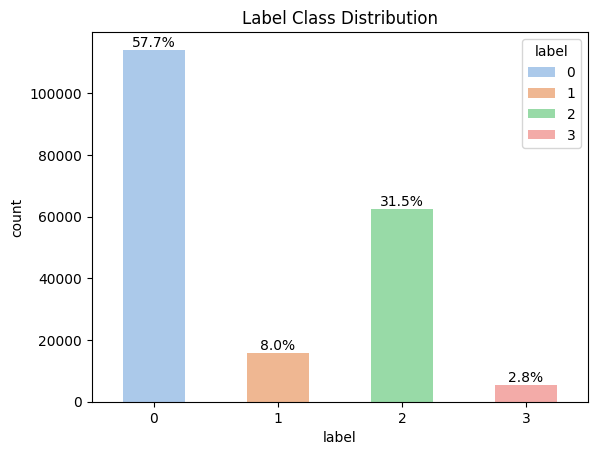

In [24]:
fig,ax=plt.subplots() # To intialize the canvas and plot
    
x=sns.countplot(x=df_eda['label'],hue=df_eda['label'],palette='pastel',ax=ax,width=0.5)

total=len(df_eda)

for c in ax.containers:
    ax.bar_label(c, fmt=lambda x: f'{(x/total)*100:.1f}%') # To annotate to each bar in the plot
    
ax.set_title("Label Class Distribution")  # To set title in the plot
plt.show()

### The imbalance ratio for a class distribution is defined as:

$$
\text{Imbalance Ratio} =
\frac{\text{Number of samples in the majority class}}
{\text{Number of samples in the minority class}}
$$

In [25]:
l=df_eda['label'].value_counts()
imbalance_ratio=l.max() / l.min()
print(f"The imbalance ratio is: {round(imbalance_ratio)}:1")

The imbalance ratio is: 21:1


- The dataset was highly imbalanced.
- To address this, techniques such as oversampling and undersampling are utilized in general.
- But, since there were 198K rows, undersampling could have caused severe loss of information and oversampling could have introduced duplicated samples which could have lead to overfitting. It could have also significantly increased the number of samples.
- Hence, to deal with this, the **class_weight** parameter was used to assign higher weights to minority classes.

## Text Analysis

### Sampling Comments from Each Class

In [26]:
for label in df_eda['label'].unique():
    print(f"\nClass {label} samples\n")
    print(df_eda[df_eda['label'] == label]['comment'].sample(2, random_state=55).values)


Class 2 samples

["Dude I don't know what locker rooms you and Trump hang out in but I play a lot of sports and we don't spend time talking that kind of trash..  The focus is on staying in shape and scoring points.  Ridiclue in real locker rooms ends up with being out the door."
 "This is excellent Elizabeth, thanks for writing.. Pay no attention to the negative comments. These people are too dumb to understand what you're saying."]

Class 0 samples

["Would that be the aotg same 'electoral strategy' that set up Tom Mulcair for the steep fall."
 'It\'s too late, Republican\'s are **already** being "primaried from the right" by Steve Bannon.  So, "working with Democrats" is not, and has not, been the problem for Republicans.  If they did start working with Dems, it would get worse for the Repubs that did.']

Class 1 samples

['It started that way, but now is used for all LGBTQ who are rp aboriginal.'
 '"Look at my African American over here" PG, PG, POTUS, DT']

Class 3 samples

['Actu

### Most Common Words

In [27]:
def clean_comment(comment):
    if pd.isna(comment):
        return ""
    text = str(comment).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_eda['clean_comment'] = df_eda['comment'].astype(str).apply(clean_comment)

total_stopwords= set(STOPWORDS).union(['will','dont','people'])
words= " ".join(df_eda['clean_comment'])
words=words.split()
words = [word for word in words if word not in total_stopwords]
word_series = pd.Series(words)
word_series.value_counts().head(10)

trump    29437
one      28114
us       21958
now      16878
time     16511
think    16413
know     15370
even     15164
many     15113
right    14409
Name: count, dtype: int64

### Most Common Words by Class

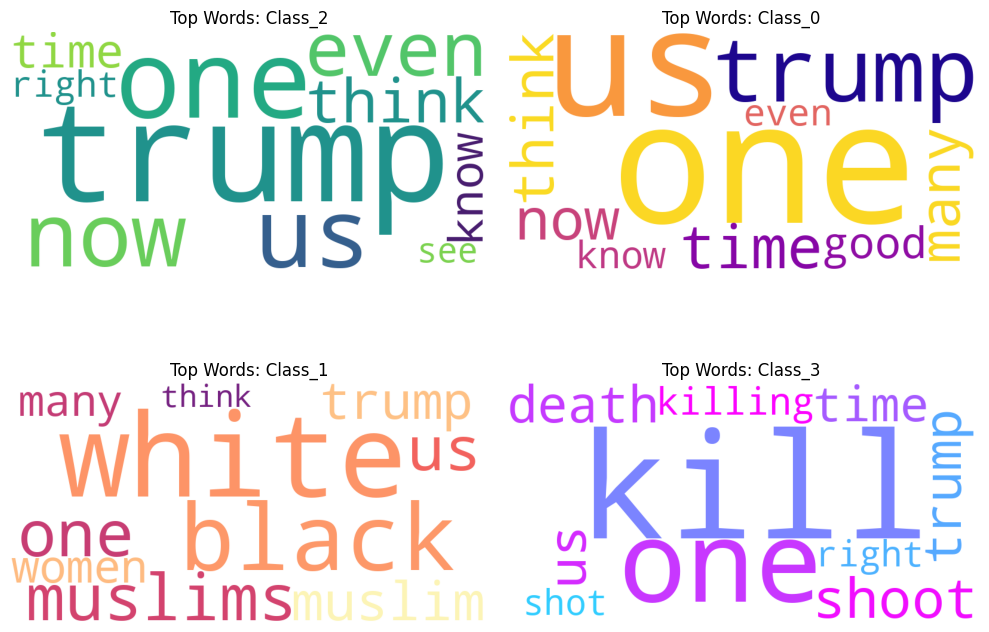

In [28]:
labels = df_eda['label'].unique()
colormaps = ['viridis', 'plasma', 'magma', 'cool']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i in range(len(labels)):
    label = labels[i]
    data = df_eda[df_eda['label'] == label]['clean_comment']
    words = " ".join(data).split()
    
    words = [word for word in words if word not in  total_stopwords]
    word_series = pd.Series(words)
    top_words = word_series.value_counts().head(10)
    
    wc = WordCloud(width=800, height=400, background_color='white',colormap=colormaps[i]).generate_from_frequencies(top_words.to_dict())
    
    axes[i].imshow(wc)
    axes[i].set_title(f"Top Words: Class_{label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### The observations were as follows:

- The samples showed variation in tone, ranging from neutral discussions to aggressive and offensive language.
- The samples also indicated the presence of informal language, punctuation mistakes, and noisy text (URLs and special characters).
- There was noticeable overlap in language patterns across the classes.
- Class 0 samples reflected relatively neutral comments.
- Class 2 samples showed some overlap in vocabulary with other classes.
- Class 1 samples indicated hateful and discriminatory comments.
- Class 3 samples indicated violent and offensive comments.

## Univariate Analysis

### Distribution of Numerical Features

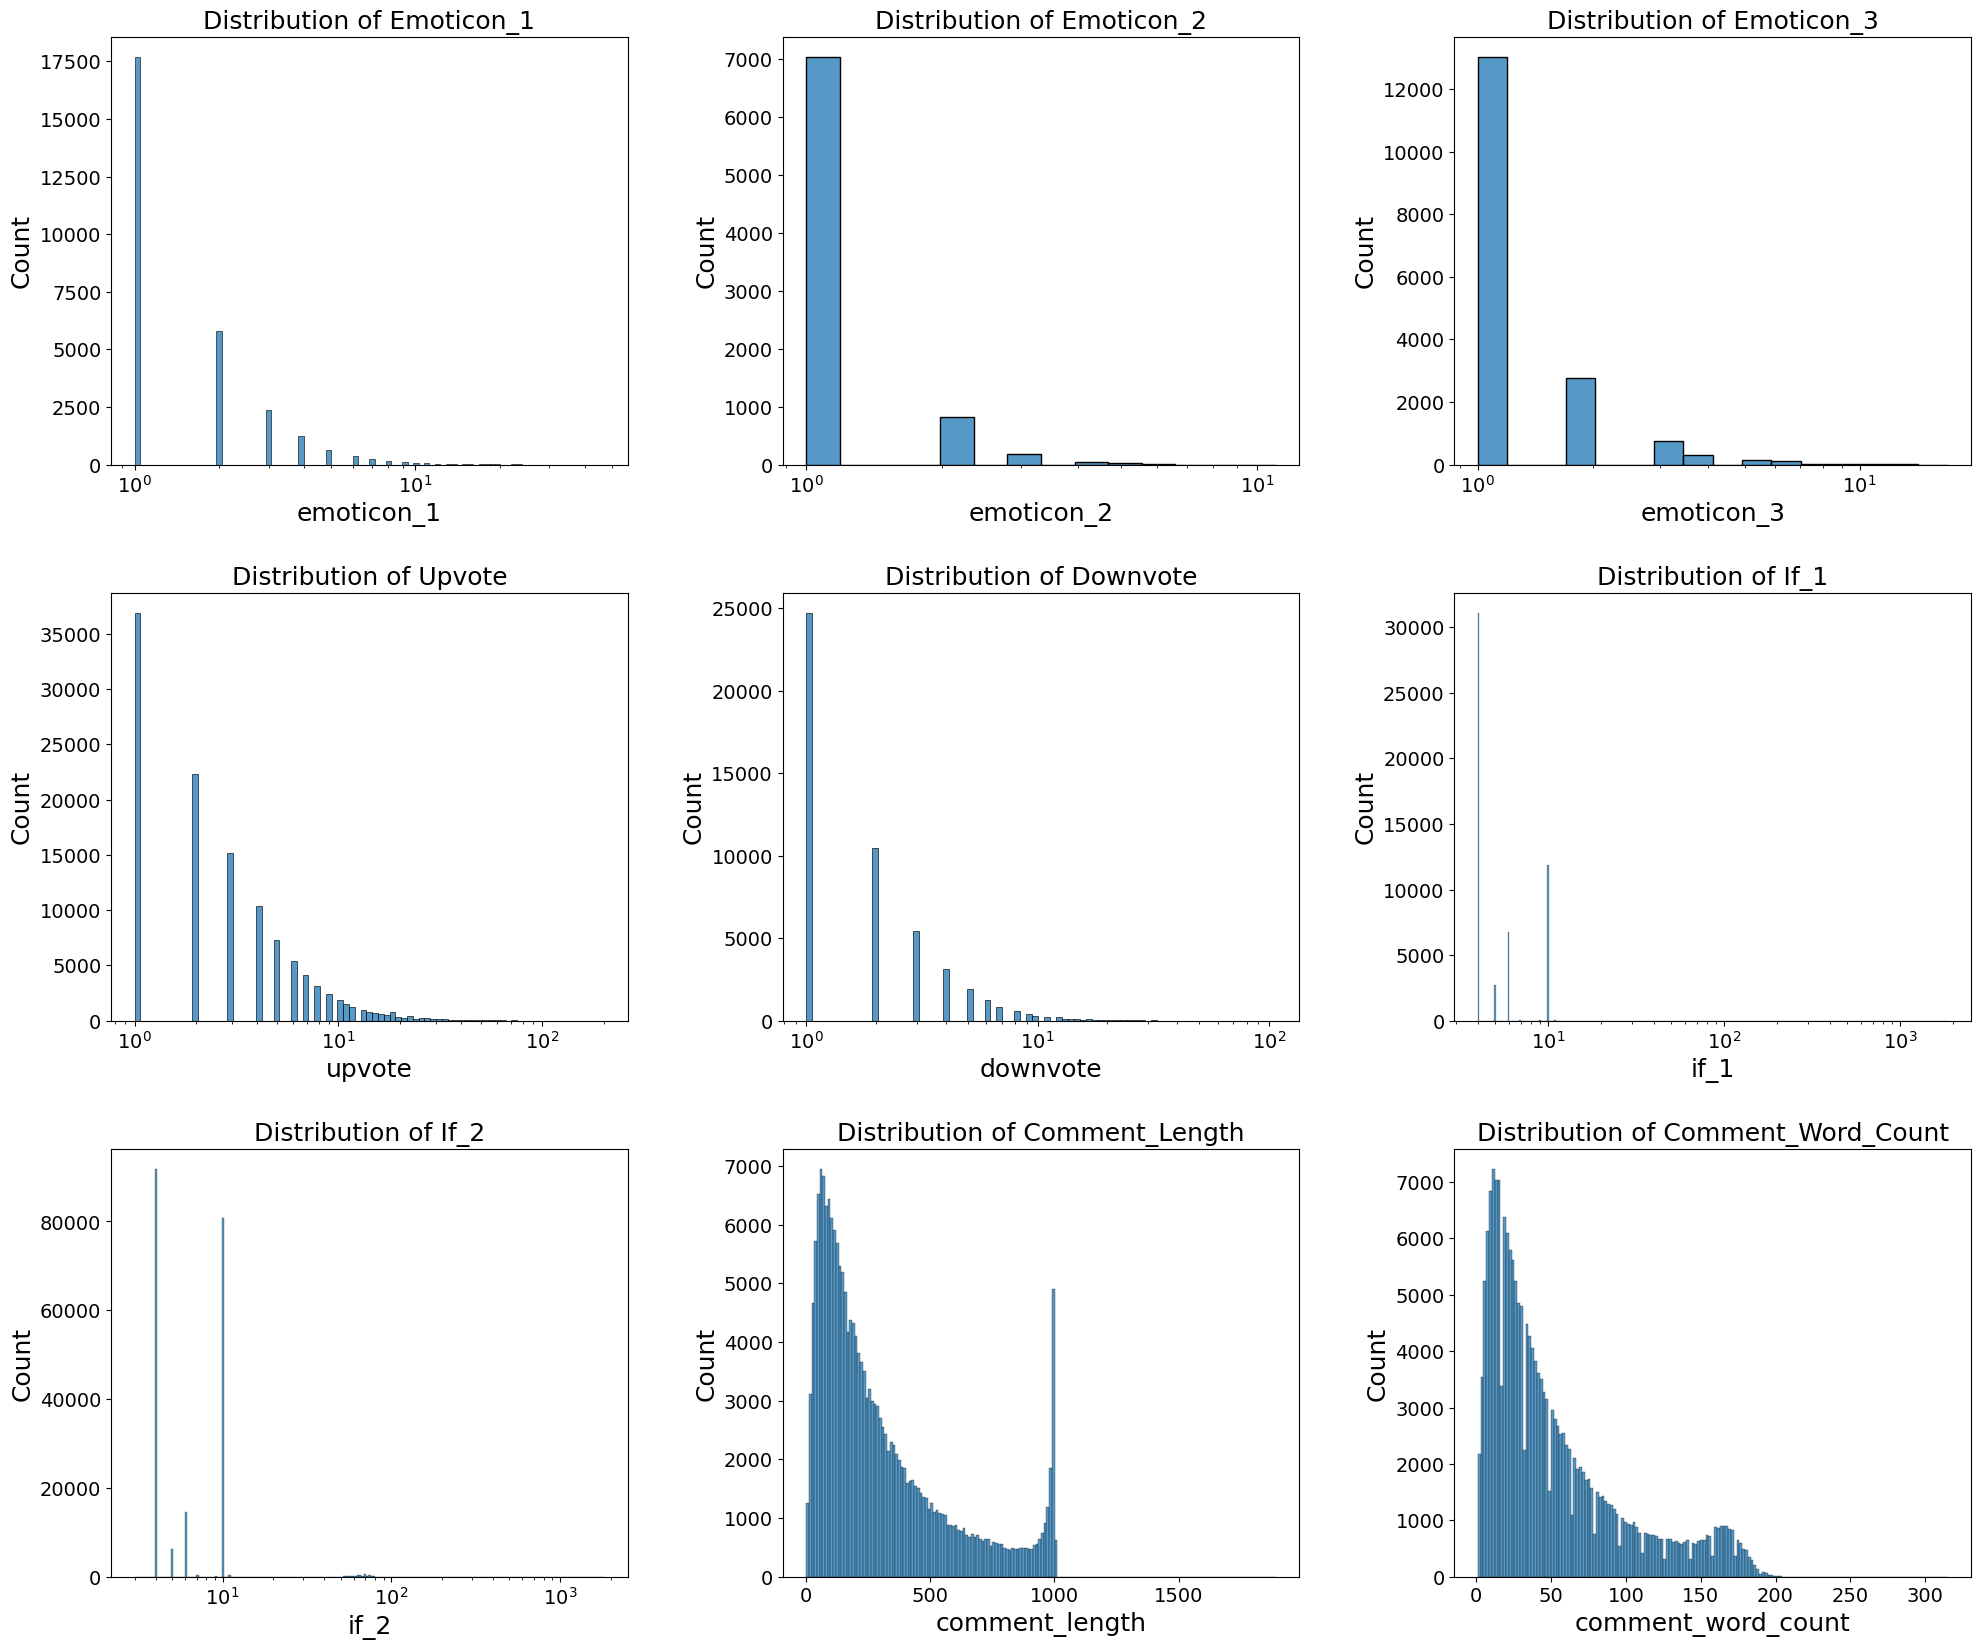

In [29]:
fig,axes=plt.subplots(3,3,figsize=(24,20)) # To set the dimensions of the canvas and allocate space for 9 subplots
axes = axes.flatten()  # To easily access each individual plot rather than using nested loops

cols=['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','comment_length','comment_word_count']
l=len(cols)

for i in range(l):
    feature=cols[i]
    if feature not in ['comment_length','comment_word_count']:
        sns.histplot(df_eda[feature],ax=axes[i],log_scale=True)
    else:
        sns.histplot(df_eda[feature],ax=axes[i])

    axes[i].set_xlabel(feature, fontsize=18)
    axes[i].set_ylabel('Count', fontsize=18) 
    axes[i].tick_params(axis='both',labelsize=14)
    axes[i].set_title("Distribution of "+feature.title(),fontsize=18)

plt.subplots_adjust(hspace=0.3,wspace=0.3) #To manually adjust the padding between subplots and prevent overlapping
plt.show()

### The observations were as follows:

- All numerical features appeared right skewed.
- The **if_2** and **comment_length** features appeared to be bimodal.

### Distribution of Categorical Features

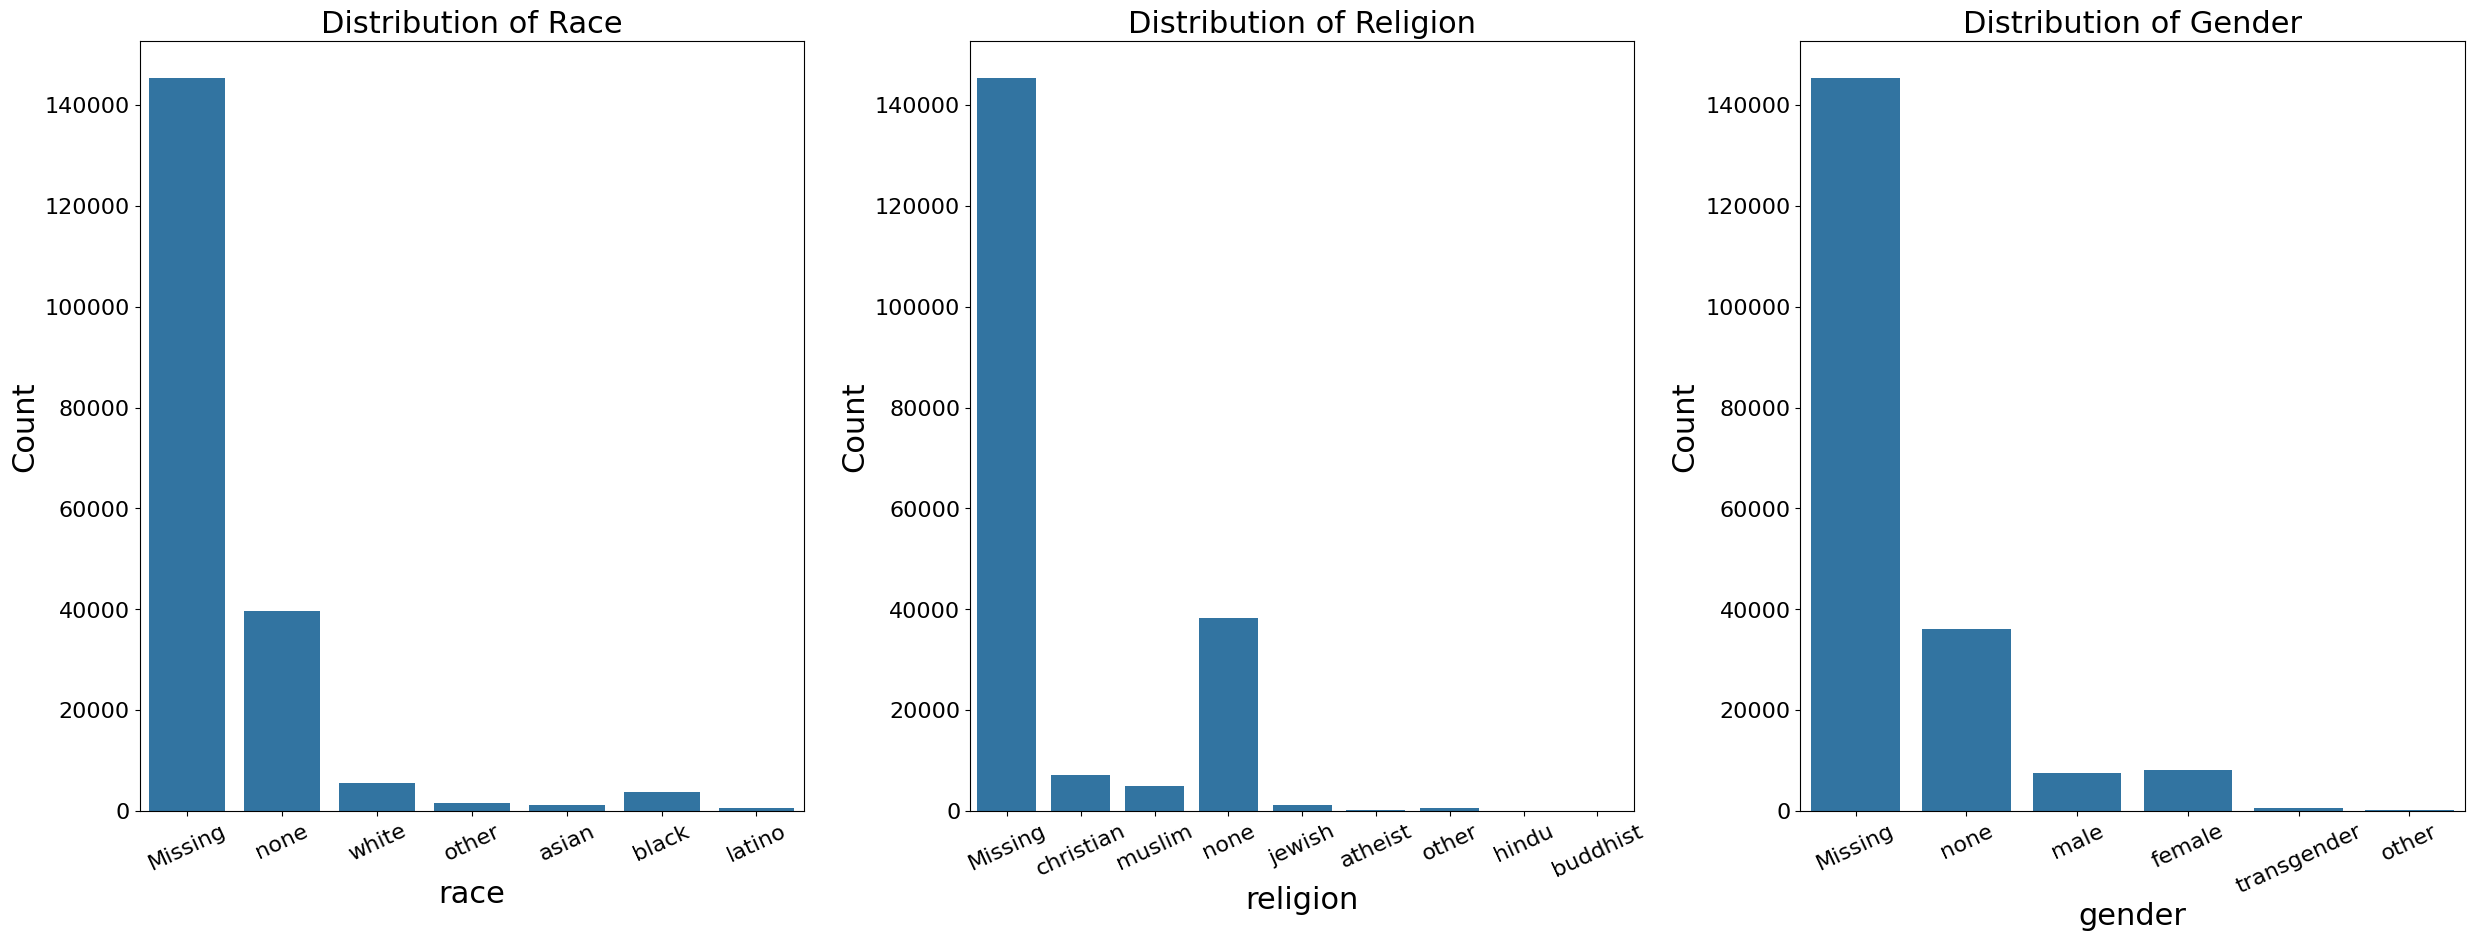

In [30]:
fig,axes=plt.subplots(1,3,figsize=(30,10)) # To set the dimensions of the canvas and allocate space for 3 subplots
axes = axes.flatten()

cols=['race','religion','gender']
l=len(cols)

for i in range(l):
    feature=cols[i]
    sns.countplot(x=df_eda[feature],ax=axes[i])

    axes[i].set_xlabel(feature, fontsize=22)
    axes[i].set_ylabel('Count', fontsize=22) 
    axes[i].tick_params(axis='both',labelsize=16)
    axes[i].set_title("Distribution of "+feature.title(),fontsize=22)
    axes[i].tick_params(axis='x', rotation=25)

plt.subplots_adjust(wspace=0.25)
plt.show()

### The observations were as follows:

- As observed earlier, a large proportion of values (~75%) were missing in the categorical features. After imputation the, "Missing" category dominated, followed by the "none" category.

### Distribution of Temporal Features

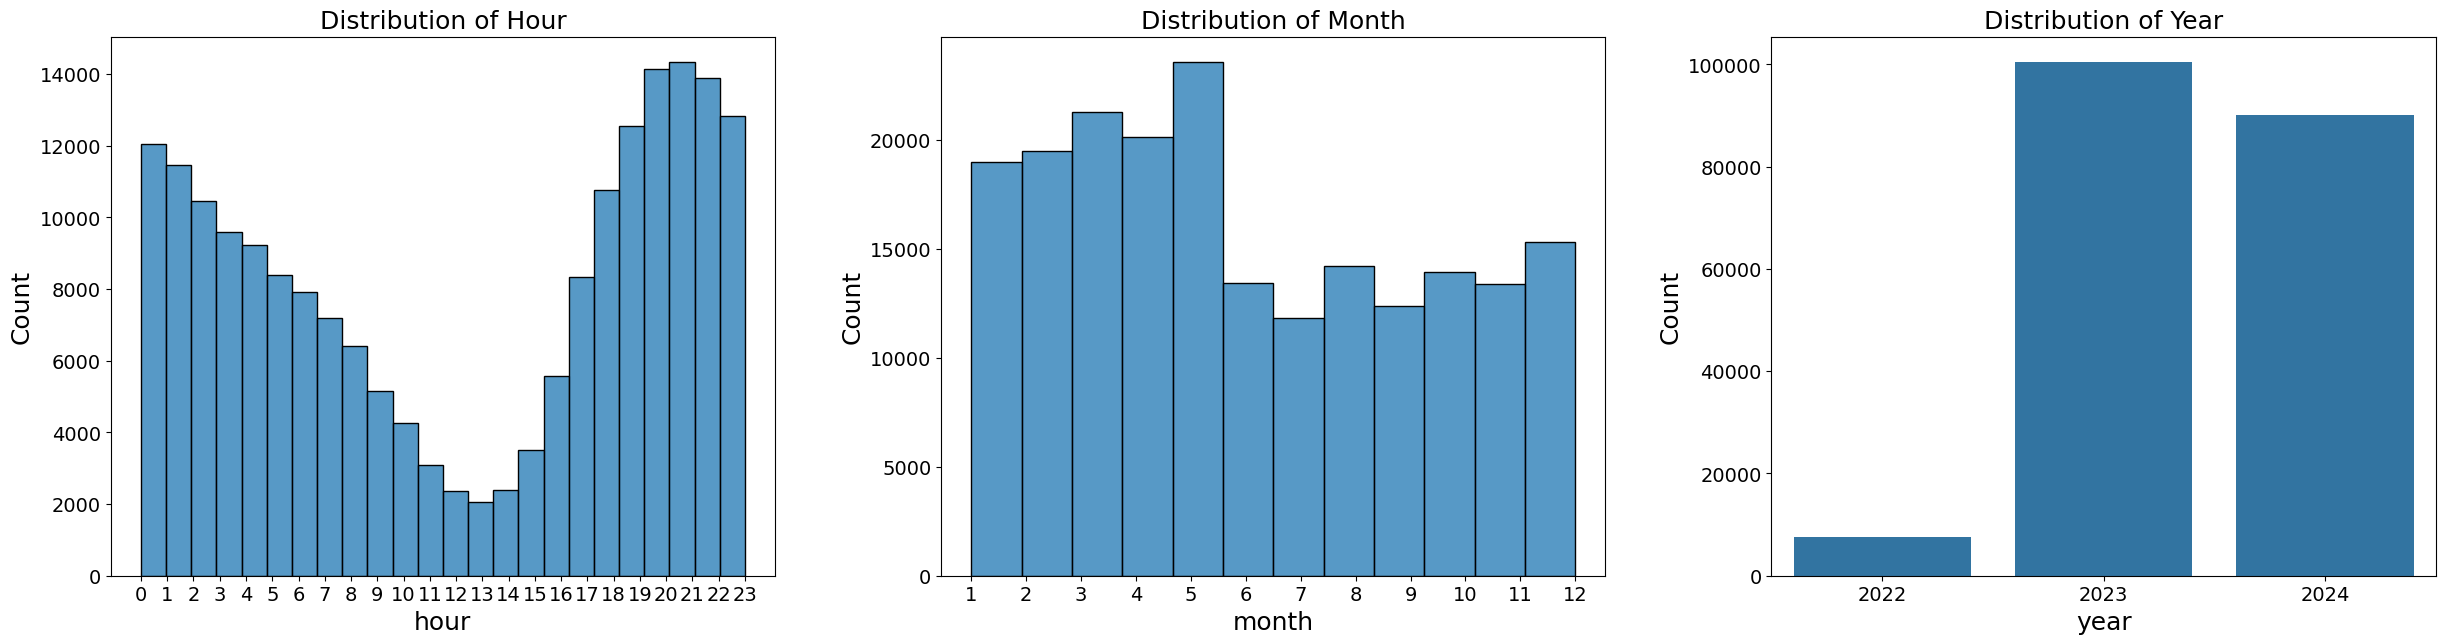

In [31]:
fig,axes=plt.subplots(1,3,figsize=(30,7))
axes=axes.flatten()

cols=['hour','month','year']

for i in range(len(cols)):
    feature=cols[i]
    if feature=='hour':
        sns.histplot(x=df_eda[feature],ax=axes[i],bins=24)
    elif feature=='month':
        sns.histplot(x=df_eda[feature],ax=axes[i],bins=12)
    else:
        sns.countplot(data=df_eda,x=feature,ax=axes[i])

    axes[i].set_xlabel(feature, fontsize=18)
    axes[i].set_ylabel('Count', fontsize=18) 
    axes[i].tick_params(axis='both',labelsize=14)
    axes[0].set_xticks(range(0,24))
    axes[1].set_xticks(range(1,13))
    axes[i].set_title("Distribution of "+feature.title(),fontsize=18)

plt.subplots_adjust(wspace=0.25)
plt.show()

### The observations were as follows: 

- The number of comments posted were higher during early morning hours and late evening hours.
- The month-wise comment distribution appeared relatively uniform, with higher values during the May month.
- Most of the comments were from year 2023, and 2024, with fewer comments from 2022.
- The hour feature appeared to be bimodal and since time is cyclical, to better represent temporal patterns, sine and cosine transformations were used to transform the cyclic linear patterns into a circular patterns so that the difference in the case of hour 0 and hour 23 is same as the difference between other hours.

## Bivariate Analysis

### Class-Wise Distribution of Numerical Features

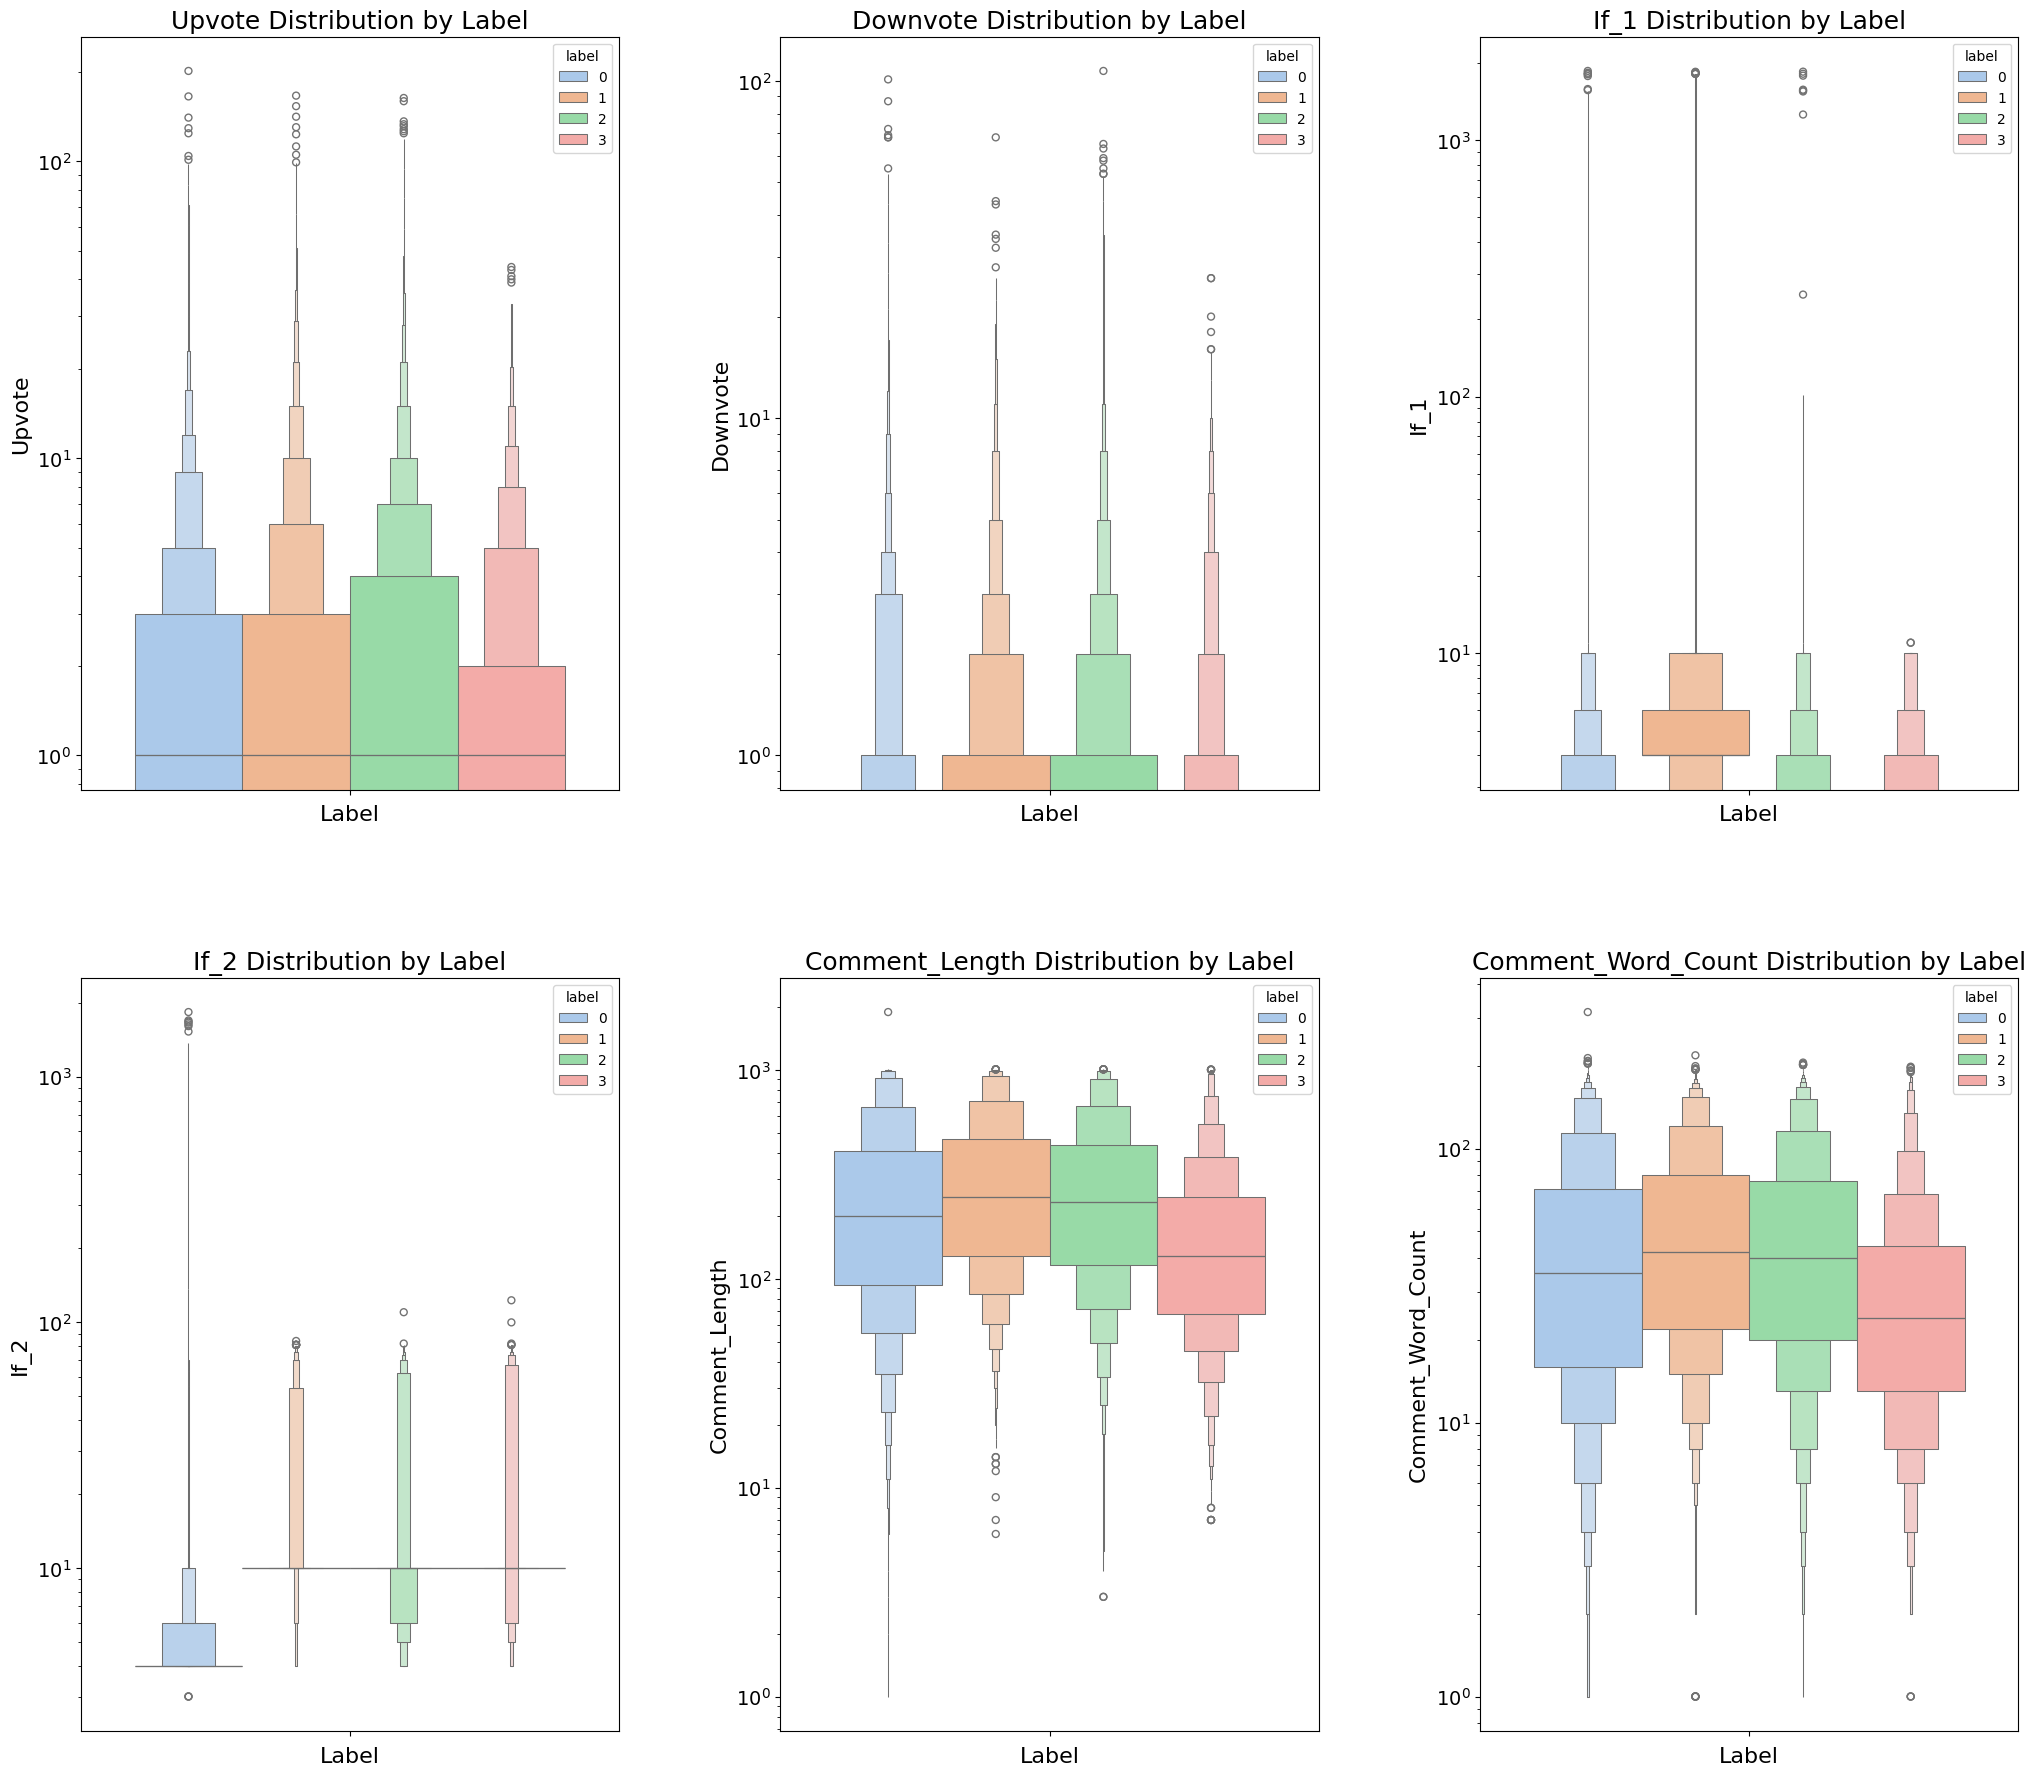

In [32]:
fig,axes=plt.subplots(2,3,figsize=(25,22))
axes=axes.flatten()

cols=['upvote','downvote','if_1','if_2','comment_length','comment_word_count']

for i in range(len(cols)):
    feature=cols[i]
    sns.boxenplot(df_eda,y=feature,ax=axes[i],hue='label',palette='pastel')
       
    axes[i].set_ylabel(feature.title(), fontsize=16)
    axes[i].set_xlabel('Label', fontsize=16) 
    axes[i].tick_params(axis='both',labelsize=14)
    axes[i].set_title(feature.title()+" Distribution by Label",fontsize=18)
    axes[i].set_yscale("log")

plt.subplots_adjust(hspace=0.25,wspace=0.3)
plt.show()

### The observations were as follows:
- Most features showed similar median values across classes, indicating limited separation. However, the **if_2** feature showed noticeable differences in median values, suggesting stronger predictive signal.
- Features such as **upvote**, **downvote**, **comment_length** and **comment_word_count** showed significant overlap in their Inter-Quartile Ranges (IQRs) across classes which implied limited prediction signals from these features.
- The boxen plot showed tall boxes across classes which depicted high variance in the features.

### Class-Wise Distribution of Categorical Features

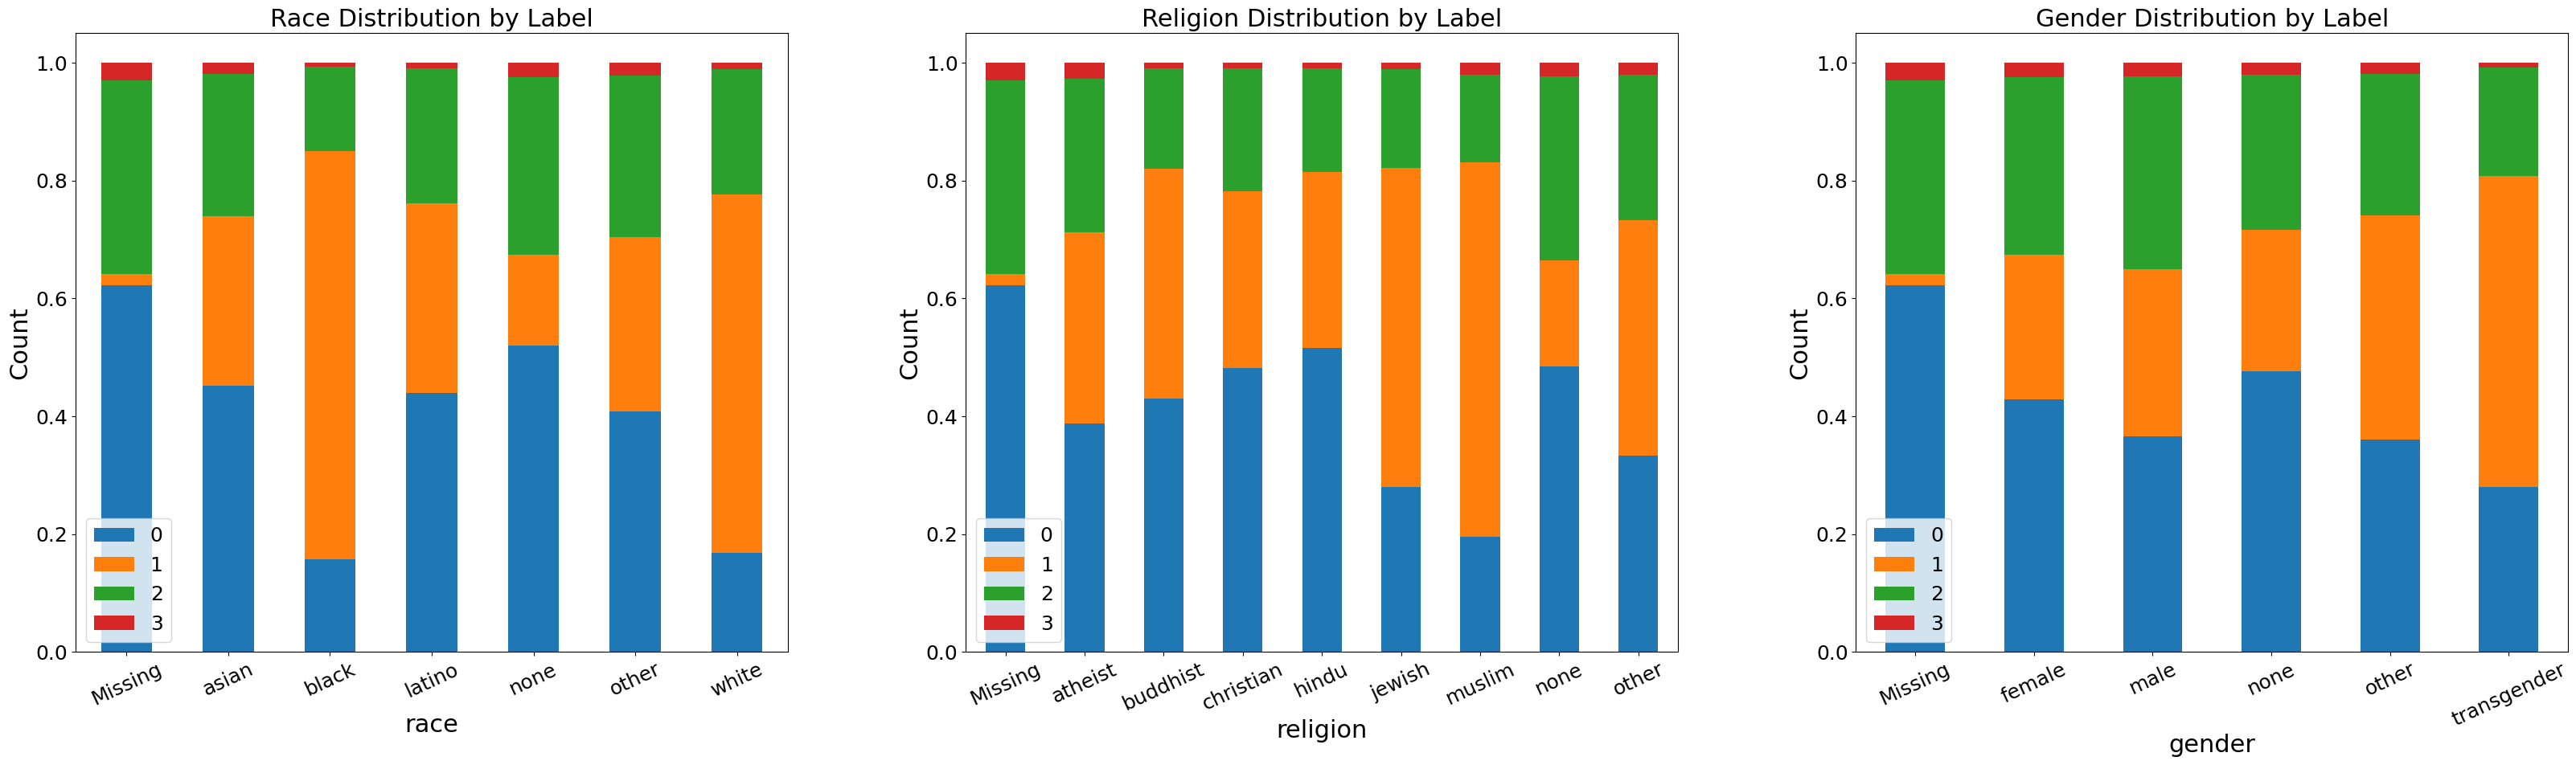

In [33]:
fig,axes=plt.subplots(1,3,figsize=(40,10))
axes=axes.flatten()

cols=['race','religion','gender']
sns.color_palette("tab10")

for i in range(len(cols)):
    feature=cols[i]
    ct = pd.crosstab(df_eda[feature], df_eda['label'], normalize='index')
    ct.plot(kind='bar',stacked=True,ax=axes[i])

    axes[i].set_xlabel(feature, fontsize=22)
    axes[i].set_ylabel('Count', fontsize=22) 
    axes[i].tick_params(axis='both',labelsize=18)
    axes[i].set_title(feature.title()+" Distribution by Label",fontsize=22)
    axes[i].legend(fontsize=18)
    axes[i].tick_params(axis='x', rotation=25)

plt.subplots_adjust(wspace=0.25)
plt.show()

### The observations were as follows:
- The categorical features showed a strong association with **Class 1** despite it being a minority class.
- **Class 0** and **Class 1** dominated across most categoires.
- **Class 2** was underrepresented in all categorical distributions despite being a majority class.

### Class-Wise Distribution of Temporal Features

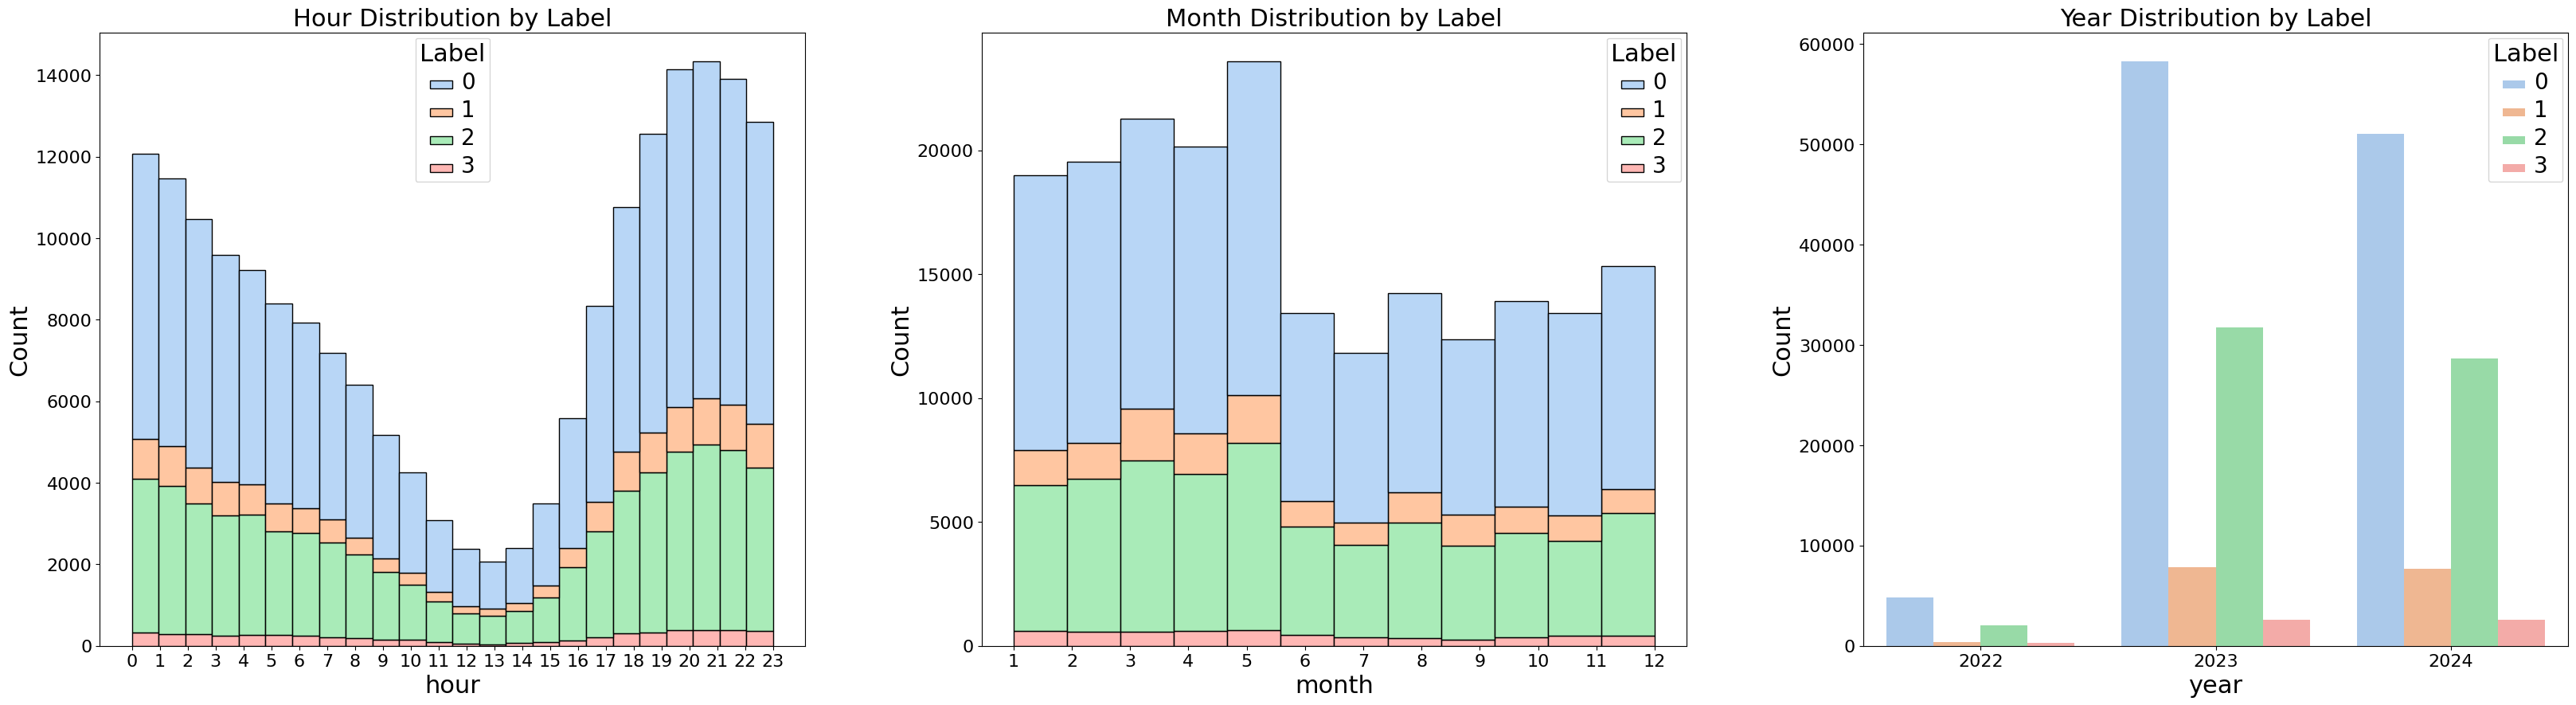

In [34]:
fig,axes=plt.subplots(1,3,figsize=(40,10))
axes=axes.flatten()

cols=['hour','month','year']

for i in range(len(cols)):
    feature=cols[i]
    if feature=="hour":
        sns.histplot(data=df_eda,x=feature,bins=24,hue=df_eda["label"],multiple="stack",palette="pastel",ax=axes[i])
        axes[i].set_xticks(range(24))
        
    elif feature=="month":
        sns.histplot(data=df_eda,x=feature,bins=12,hue=df_eda["label"],multiple="stack",palette="pastel",ax=axes[i])
        axes[i].set_xticks(range(1,13))
       
    else:
        sns.countplot(x=df_eda[feature],ax=axes[i],hue=df_eda['label'],palette="pastel")
    
    axes[i].set_xlabel(feature, fontsize=22)
    axes[i].set_ylabel('Count', fontsize=22) 
    axes[i].tick_params(axis='both',labelsize=16)
    axes[i].set_title(feature.title()+" Distribution by Label",fontsize=22)
    legend = axes[i].get_legend()
    legend.set_title("Label")
    for text in legend.get_texts():
        text.set_fontsize(20)
    legend.get_title().set_fontsize(22)
   

plt.subplots_adjust(wspace=0.25)
plt.show()

### The observations were as follows:
- **Class 0** dominated across all temporal features, followed by **Class 2**, reflecting overall class imbalance.
- **Classes 1 and 3** were underrepresented across all temporal features.

## Multivariate Analysis

### Correlations between Numerical Features and Labels

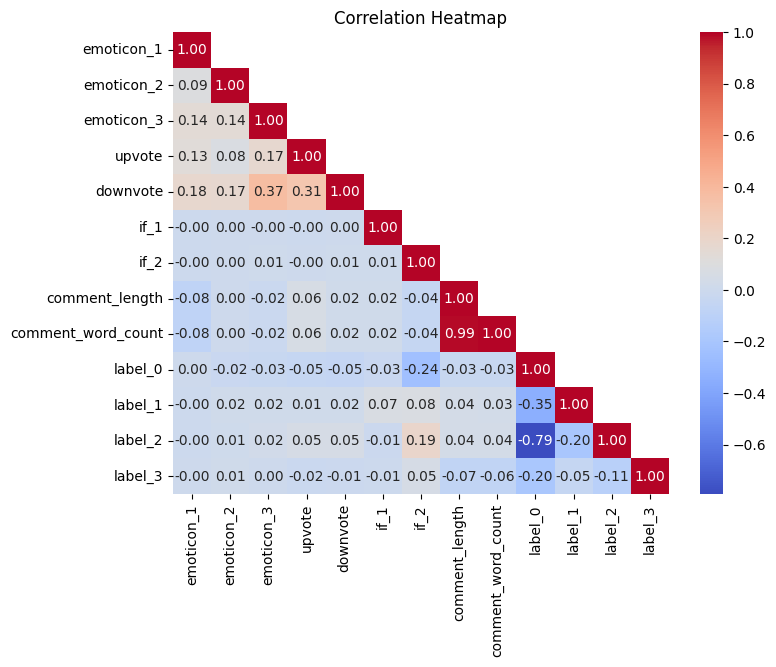

In [35]:
label_dummies=pd.get_dummies(df_eda['label'], prefix='label') #To One-Hot Encode target variable, with prefix set as label

num_cols=['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','comment_length','comment_word_count']

df_eda_corr=pd.concat([df_eda[num_cols],label_dummies],axis=1) # To combine numerical features with labels
corr_matrix=df_eda_corr.corr()  #To compute the pairwise correlation matrix

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap='coolwarm',cbar=True,mask=np.triu(corr_matrix,k=1))
plt.title('Correlation Heatmap')
plt.show()

### The observations were as follows:
- Many of the features showed low correlation with target labels, indicating limited linear relationships.
- The **if_2** feature showed relatively higher correlation with label 0 and 2.
- Multicollinearity was minimal among most features.
- However, **comment_length** and **comment_word_count** showed strong positive correlation with each other, as both were derived from the same **comment** feature.

# Train-Validation Split

In [4]:
df_train.dropna(subset='comment',inplace=True) # Dropping the empty comment 

y=df_train['label']  # Seperating the label from the features

df_train.drop('label',inplace=True,axis=1) # Removing the label from the feature dataframe

X_train,X_val,y_train,y_val=train_test_split(df_train,y,test_size=0.2,random_state=5,stratify=y) # Splitting the data into Train and Validation Sets. stratify=y enusures that the label distribution is maintained across the train and validation set.

# Data Cleaning and Preprocessing

### A function transformer was used to clean the dataset by performing the following steps:

- Extraction of temporal features such as **hour**, **month**, **year**, along with **comment_word_count**.
  
- Handling of missing values in the **comment** feature and replacement of multiple spaces with a single space.

- Conversion of the **disability** feature into a numerical binary feature.

- Dropping of **created_date** and **post_id** features.

In [37]:
def clean_preprocess(df):
    
    df = df.copy()
    
    df['created_date'] = pd.to_datetime(df['created_date'])
    
    df['hour'] = df['created_date'].dt.hour #Splitting the created_date columnn into hour, month and year to uncover patterns
    df['month'] = df['created_date'].dt.month
    df['year'] = df['created_date'].dt.year

    df['comment'] = (df['comment'].fillna("").str.replace(r'\s+', ' ', regex=True).str.strip()) # filling empty comments and replacing multiple spaces with a single space
    df['comment_word_count'] = df['comment'].str.split().str.len() #Splitting the comment column into comment_word_count
    
    df['disability'] = df['disability'].fillna(0).astype(int)
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    df.drop(['created_date','post_id'],axis=1,inplace=True,errors='ignore')
    
    return df
    
clean_preprocess_transformer=FunctionTransformer(clean_preprocess)

## Text Representation (TF-IDF Vectorization)

- The **comment** feature was transformed into numerical vectors using TF-IDF Vectorization.

- TF-IDF assigns higher importance to informative words while reducing the weight of frequently occurring terms.

- This representation enables machine learning models to effectively learn patterns from textual data.

- Numerical features were scaled using the **StandardScaler** to ensure proper scaling for model training.
  
- Categorical features were imputed using the **SimpleImputer** and then, encoded using the **One-Hot-Encoder** to make them suitable for model training.

- These preprocessing steps were combined using a ColumnTransformer to apply them simultaneously to the features.

In [38]:
col_trans=ColumnTransformer([
    ("tfidf", TfidfVectorizer(max_features=50000), 'comment'),   # using max_features = 50,000 ensures the model converges well in time
    ("r_scale",StandardScaler(),['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','hour','month','year','comment_word_count']),
    ("impute_encode",Pipeline([
        ("si",SimpleImputer(strategy="constant",fill_value="Missing")),
        ("ohe",OneHotEncoder(drop='first',handle_unknown='ignore'))])
     ,['race','religion','gender'])
],remainder='passthrough')  # To allow the binary variable "disability" to passthrough

# Baseline Model

- Since this was a multiclass text classification problem, Logistic Regression was chosen as the baseline model.
  
- Logistic Regression is well-suited for high-dimensional sparse data such as TF-IDF vectors and provides a strong and interpretable baseline.

In [39]:
base_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LogisticRegression(class_weight='balanced',max_iter=1000,random_state=5)) #setting class_weight = balanced allows the model to handle class imbalance
]) 

set_config(display='diagram')
base_pipeline

Pipeline(steps=[('clean_preprocess',
                 FunctionTransformer(func=<function clean_preprocess at 0x7b933b76d620>)),
                ('encode_scale',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=50000),
                                                  'comment'),
                                                 ('r_scale', StandardScaler(),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'upvote',
                                                   'downvote', 'if_1', 'if_2',
                                                   'hour', 'month', 'year',
                                                   'comment_word_count']),
                                                 ('impute_encode',
                                                  Pipeline(steps=[('si',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['race', 'religion',
                                                   'gender'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=5))])

In [40]:
base_pipeline.fit(X_train,y_train)

y_val_pred=base_pipeline.predict(X_val)
y_train_pred=base_pipeline.predict(X_train)

macro_f1_val=f1_score(y_val,y_val_pred,average='macro')
macro_f1_train=f1_score(y_train,y_train_pred,average='macro')

print("Training Macro F1-Score:",round(macro_f1_train,4))
print("Validation Macro F1-Score:",round(macro_f1_val,4))

Training Macro F1-Score: 0.8621
Validation Macro F1-Score: 0.7968


- ### *Training Macro F1-Score:* **0.8621**
  
- ### *Validation Macro F1-Score:* **0.7968**
  
- The model showed moderate signs of overfitting, as there was a moderate gap between training and validation scores.

In [41]:
print(classification_report(y_val,y_val_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22834
           1       0.68      0.86      0.76      3184
           2       0.88      0.86      0.87     12488
           3       0.49      0.80      0.61      1094

    accuracy                           0.90     39600
   macro avg       0.76      0.86      0.80     39600
weighted avg       0.91      0.90      0.90     39600



- The precision scores for minority classes was significantly lower than recall scores. This implied that the model was overpredicting these classes.
  
- The majority classes showed more balanced precision and recall scores.

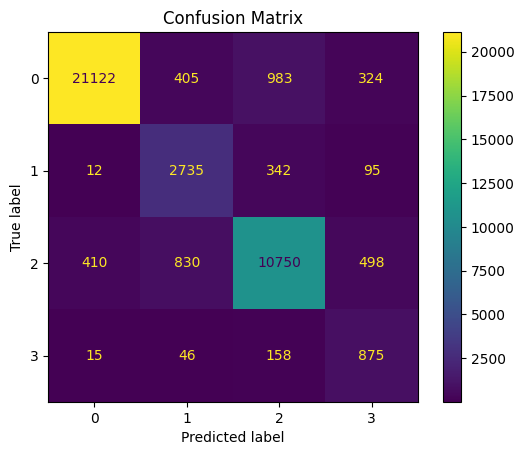

In [43]:
C=confusion_matrix(y_val,y_val_pred)
disp=ConfusionMatrixDisplay(C)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

- Class 0 was well-classified, with relatively low misclassifications.
    
- There was a significant confusion between Class 1 and Class 2, indicating overlapping feature patterns.
   
- Class 3 had relatively low false negatives, showing good recall score despite being a minority class.
  
- The most common misclassification was Class 0 being predicted as Class 2, suggesting feature overlap between these classes as well.

## TF-IDF Hyperparameter Tuning

In [ ]:
col_trans=ColumnTransformer([
    ("tfidf", TfidfVectorizer(), 'comment'),
    ("r_scale",StandardScaler(),['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','hour','month','year','comment_word_count']),
    ("impute_encode",Pipeline([
        ("si",SimpleImputer(strategy="constant",fill_value="Missing")),
        ("ohe",OneHotEncoder(drop='first',handle_unknown='ignore'))])
     ,['race','religion','gender'])
],remainder='passthrough')

tfidf_tuned_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LogisticRegression(class_weight='balanced',,max_iter=1000,random_state=5))
])

p_grid={"encode_scale__tfidf__max_features":[25000,50000,75000], # to control the vocabulary size
        "encode_scale__tfidf__max_df":[0.6, 0.8, 1.0],  # to remove very common terms
        "encode_scale__tfidf__min_df": [1, 2, 5],   # to remove very rare terms
        "encode_scale__tfidf__ngram_range": [(1, 1), (1, 2)], # to control the sequence of words; unigrams and bigrams
        "encode_scale__tfidf__sublinear_tf":[True,False]  # To apply log scaling to term frequency to handle very frequent terms
       }

In [ ]:
cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=5)

tfidf_search=RandomizedSearchCV(tfidf_tuned_pipeline,p_grid,scoring="f1_macro",cv=cv,verbose=3,random_state=5)

tfidf_search.fit(X_train,y_train)

print(tfidf_search.best_params_)
print(tfidf_search.best_score_)

- ### *Cross-Validated Macro F1-Score:* **0.7979**

- ### *Best Parameters:*
### **{'encode_scale__tfidf__sublinear_tf': True, 'encode_scale__tfidf__ngram_range': (1, 2), 'encode_scale__tfidf__min_df': 2, 'encode_scale__tfidf__max_features': 75000, 'encode_scale__tfidf__max_df': 0.8}**

- This optimized TF-IDF configuration was used for all subsequent models to ensure consistency and fair comparision.

# Feature Engineering

## Feature Transformation

- Features such as **emoticon_1/2/3, if_1, and downvote** were 0-inflated. To address this, binary transformations were applied to capture presence or absence of these signals.
  
- Transforming these features into binary indicators also helps to reduce skewness and allows models to learn meaningful patterns.

In [44]:
df_eda_FE=df_eda.copy()

df_eda_FE['emoticon_1_binary']=(df_eda_FE['emoticon_1']>0).astype(int)
df_eda_FE['emoticon_2_binary']=(df_eda_FE['emoticon_2']>0).astype(int)
df_eda_FE['emoticon_3_binary']=(df_eda_FE['emoticon_3']>0).astype(int)
df_eda_FE['if_1_binary']=(df_eda_FE['if_1']>0).astype(int)
df_eda_FE['downvote_binary']=(df_eda_FE['downvote']>0).astype(int)
df_eda_FE['disability']=df_eda_FE['disability'].astype(int)

print("Binary Features Distribution (%)\n")
binary_cols=['emoticon_1_binary','emoticon_2_binary','emoticon_3_binary','if_1_binary','downvote_binary','disability']
for x in binary_cols:
    print(df_eda_FE[x].value_counts(normalize=True)*100,"\n")   

Binary Features Distribution (%)

emoticon_1_binary
0    85.392856
1    14.607144
Name: proportion, dtype: float64 

emoticon_2_binary
0    95.904525
1     4.095475
Name: proportion, dtype: float64 

emoticon_3_binary
0    91.330764
1     8.669236
Name: proportion, dtype: float64 

if_1_binary
0    73.446331
1    26.553669
Name: proportion, dtype: float64 

downvote_binary
0    74.563508
1    25.436492
Name: proportion, dtype: float64 

disability
0    98.614639
1     1.385361
Name: proportion, dtype: float64 



- Temporal features such as **hour** and **month** were transformed using sine and cosine transformations to capture their cyclical nature.
  
- These transformations convert linear signals into circular signals, allowing the model to better understand periodic patterns.

In [45]:
df_eda_FE["hour_sin"]= np.sin(2 *np.pi *df_eda_FE["hour"]/24)
df_eda_FE["hour_cos"]= np.cos(2 *np.pi *df_eda_FE["hour"]/24)

df_eda_FE["month_sin"]= np.sin(2 *np.pi *df_eda_FE["month"]/12)
df_eda_FE["month_cos"]= np.cos(2 *np.pi *df_eda_FE["month"]/12)

- A new feature, **average_word_length** was created using **comment_length** and **comment_word_count**.
  
- This feature captures the average word length, which can indicate whether a comment contains simpler or complex vocabulary.

In [46]:
df_eda_FE['avg_word_length']=df_eda_FE['comment_length']/df_eda_FE['comment_word_count']

### Log and Yeo-Johnson Transformation of  Skewed Features
- Features such as **upvote, if_2, avg_word_length and comment_word_count** were highly right skewed.
  
- Since linear models perform better with more symmetric feature distributions, transformations were applied to reduce skewness.

- Both **Log Transformation** and **Yeo-Johnson Transformation** were evaluated to determine the more effective transformation to treat skewness.

In [47]:
cols=['upvote','if_2','avg_word_length','comment_word_count']
for x in cols:
    lmax=st.yeojohnson_normmax(df_eda_FE[x]) # This helps to find optimal yeo-johnson transformation parameter for each feature
    yeo_john_feature=st.yeojohnson(df_eda_FE[x],lmbda=lmax)
    print(f"Feature: {x:18} |Raw Feature Skewness: {df_eda_FE[x].skew():8.3f} |Log-Transformed Skewness: {np.log1p(df_eda_FE[x]).skew():8.3f} |Yeo-Johnson Skewness: {st.skew(yeo_john_feature):.3f}")

Feature: upvote             |Raw Feature Skewness:    7.103 |Log-Transformed Skewness:    0.802 |Yeo-Johnson Skewness: 0.198
Feature: if_2               |Raw Feature Skewness:   67.321 |Log-Transformed Skewness:    1.823 |Yeo-Johnson Skewness: 0.235
Feature: avg_word_length    |Raw Feature Skewness:   42.509 |Log-Transformed Skewness:    6.965 |Yeo-Johnson Skewness: -1.251
Feature: comment_word_count |Raw Feature Skewness:    1.231 |Log-Transformed Skewness:   -0.326 |Yeo-Johnson Skewness: -0.029


- Yeo-Johnson Transformation effectively reduced skewness closer to zero as compared to Log Transformation, and was therefore used during preprocessing.

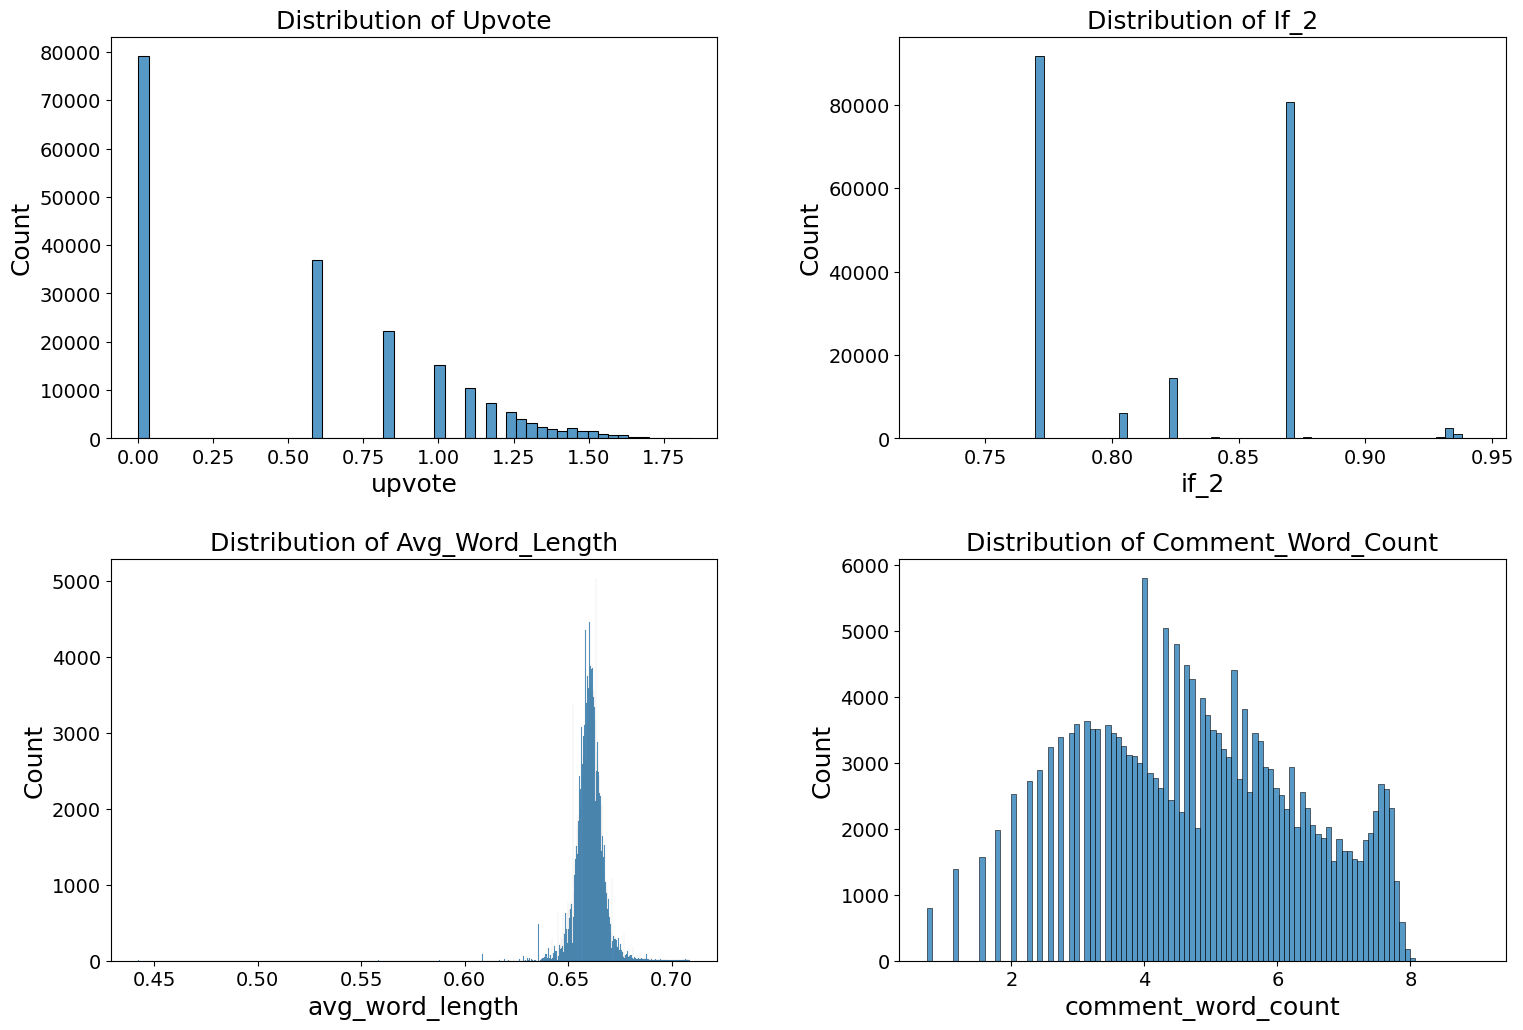

In [48]:
fig,axes=plt.subplots(2,2,figsize=(18,12))
axes=axes.flatten()

cols=['upvote','if_2','avg_word_length','comment_word_count']

for i in range(len(cols)):
    feature=cols[i]
    lmax=st.yeojohnson_normmax(df_eda_FE[feature]) # To find the best lambda value
    feature_t = st.yeojohnson(df_eda_FE[feature],lmbda=lmax) # Using the best lambda value, transforming the feature
    sns.histplot(feature_t,ax=axes[i])

    axes[i].set_xlabel(feature, fontsize=18)
    axes[i].set_ylabel('Count', fontsize=18) 
    axes[i].tick_params(axis='both',labelsize=14)
    axes[i].set_title("Distribution of "+feature.title(),fontsize=18)

plt.subplots_adjust(hspace=0.3,wspace=0.3)
plt.show()

## Feature Selection using Mutual Information

- Mutual Information is a filter-based model-agnostic technique that measures the dependency between a feature and the target variable.
  
- It quantifies the amount of information obtained about the target variable from a given feature.

- It is capable of capturing both linear and non-linear relationships between features.

- Seperate preprocessing functions were used to evaluate feature importance for both raw and transformed features.

- TF-IDF features were not used with Mutual Information due to their high dimensionality, which makes feature selection computationally expensive.

- Additionally, the sparse and noisy nature of TF-IDF features could have lead to less stable feature importance estimates.

In [49]:
def clean_preprocess_selection_transformed(df):
    
    df=df.copy()
    
    df['created_date']=pd.to_datetime(df['created_date'])
    
    df['hour']=df['created_date'].dt.hour #Splitting the created_date columnn into hour, month and year to uncover patterns
    df['month']=df['created_date'].dt.month
    df['year']=df['created_date'].dt.year
    
    df["hour_sin"]= np.sin(2 *np.pi *df["hour"]/24)
    df["hour_cos"]= np.cos(2 *np.pi *df["hour"]/24)
    
    df["month_sin"]= np.sin(2 *np.pi *df["month"]/12)
    df["month_cos"]= np.cos(2 *np.pi *df["month"]/12)
    
    df['comment'] = df['comment'].fillna("")
    df['comment_length']=df['comment'].str.len() #Splitting the comment column into comment_length and word_count
    df['comment_word_count']=df['comment'].str.split().str.len()
    df['avg_word_length'] = np.where(df['comment_word_count'] > 0,df['comment_length'] / df['comment_word_count'],0)
    

    df['disability']=df['disability'].fillna(0).astype(int)
    numeric_cols=df.select_dtypes(include=['number']).columns
    df[numeric_cols]=df[numeric_cols].fillna(0)
    df['emoticon_1_binary']= (df['emoticon_1'] > 0).astype(int)
    df['emoticon_2_binary']= (df['emoticon_2'] > 0).astype(int)
    df['emoticon_3_binary']= (df['emoticon_3'] > 0).astype(int)
    df['if_1_binary']=(df['if_1'] > 0).astype(int)
    df['downvote_binary']=(df['downvote'] > 0).astype(int)
    
    df.drop(['created_date','post_id','hour','emoticon_1','emoticon_2','emoticon_3','if_1','downvote','comment_length','month','comment'],axis=1,inplace=True,errors='ignore') #Dropping all the raw columns
    
    return df
    
clean_preprocess_transformer_transformed=FunctionTransformer(clean_preprocess_selection_transformed)



def clean_preprocess_selection_raw(df):
    
    df=df.copy()
    
    df['created_date']=pd.to_datetime(df['created_date'])
    df['hour']=df['created_date'].dt.hour #Splitting the created_date columnn into hour, month and year to uncover patterns
    df['month']=df['created_date'].dt.month
    df['year']=df['created_date'].dt.year


    df['comment'] = df['comment'].fillna("")
    df['comment_length'] = df['comment'].str.len() #Splitting the comment column into comment_length and word_count
    df['comment_word_count'] = df['comment'].str.split().str.len()
    df['avg_word_length'] = np.where(df['comment_word_count'] > 0,df['comment_length'] / df['comment_word_count'],0) # Since this feature is just extracted not transformed
    
    df['disability'] = df['disability'].fillna(0).astype(int)
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    df.drop(['created_date','post_id','comment_length','comment'],axis=1,inplace=True,errors='ignore')
    
    return df
    
clean_preprocess_transformer_raw=FunctionTransformer(clean_preprocess_selection_raw)

### Mutual Information Raw Features

In [ ]:
col_trans=ColumnTransformer([
    ("scale_features",StandardScaler(),['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','hour','month','year','comment_word_count','avg_word_length']),
    ("impute_encode",Pipeline([
        ("si",SimpleImputer(strategy="constant",fill_value="Missing")),
        ("ohe",OneHotEncoder(drop='first',handle_unknown='ignore'))])
     ,['race','religion','gender'])
],remainder='passthrough')

MI_raw_feature_eng_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer_raw),
    ('encode_scale',col_trans),
    ('mi_select',SelectKBest(score_func=mutual_info_classif)),
    ('model',LogisticRegression(class_weight='balanced',max_iter=1000,random_state=5))
])

p_grid={
    'mi_select__k':[5, 8, 10, 15, 'all']
}

cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=5)

MI_raw_search=GridSearchCV(MI_raw_feature_eng_pipeline,p_grid,scoring="f1_macro",cv=cv,verbose=3)

MI_raw_search.fit(X_train,y_train)

print(MI_raw_search.best_params_)
print(MI_raw_search.best_score_)

- ### *Cross-Validated Macro F1-Score:* **0.6127**

- ### *Best Parameter:* **{'mi_select__k': 'all'}**

### Mutual Information Transformed Features

In [ ]:
binary_features=['emoticon_1_binary', 'emoticon_2_binary', 'emoticon_3_binary','if_1_binary', 'downvote_binary', 'disability']
yeo_features=['upvote','if_2', 'comment_word_count','avg_word_length']
temporal_features=['month_sin','month_cos', 'year','hour_sin', 'hour_cos']
categorical_features=['race', 'religion', 'gender']

col_trans=ColumnTransformer([
    ("yeo_pipeline",Pipeline([("yeo", PowerTransformer(method="yeo-johnson")),("scale_yeo", StandardScaler())]),yeo_features),
    ("scale_features",StandardScaler(),temporal_features),
    ("impute_encode",Pipeline([
        ("si",SimpleImputer(strategy="constant",fill_value="Missing")),
        ("ohe",OneHotEncoder(drop='first',handle_unknown='ignore'))])
     ,categorical_features)
],remainder='passthrough')

MI_transf_feature_eng_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer_transformed),
    ('encode_scale',col_trans),
    ('mi_select',SelectKBest(score_func=mutual_info_classif)),
    ('model',LogisticRegression(class_weight='balanced',max_iter=1000,random_state=5))
])

p_grid={
    'mi_select__k':[5, 8, 10, 15, 'all']
}

cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=5)

MI_transf_search=GridSearchCV(MI_transf_feature_eng_pipeline,p_grid,scoring="f1_macro",cv=cv,verbose=3)

MI_transf_search.fit(X_train,y_train)

print(MI_transf_search.best_params_)
print(MI_transf_search.best_score_)

- ### *Cross-Validated Macro F1-Score:* **0.6182**

- ### *Best Parameter:* **{'mi_select__k': 'all'}**

### Conclusion:
- The transformed features pipeline slighty outperformed the raw features pipeline improving the score from *0.612* to *0.618* **(~ 0.006)**.
  
- Since textual features remain the most informative, combining them with these transformed features can further improve model performance.

## TF-IDF Vectorization with "char_wb" Analyzer

- The **char_wb** analyzer generates character n-grams within word boundaries, which captures subword patterns such as prefixes, suffixes, and variations.

- This makes it more robust to spelling errors and informal language, which is beneficial for minority classes containing noisy and rare text patterns.

- To leverage both word-level and subword-level information, the default **word analyzer** was combined with the **char_wb analyzer**.

- This allowed the models to capture both word-level and character-level patterns.

- Truncated SVD was not applied, as it focuses on capturing global variance and may dilute rare but important signals from minority classes, especially in the presence of class imbalance.

# Model Training and Evaluation

### The following models were trained and evaluated:
- #### Logistic Regression
- #### Linear SVC
- #### LightGBM Classifier

### Common Pipeline for Linear Models

In [50]:
def clean_preprocess_linear(df):
    
    df=df.copy()
    
    df['created_date']=pd.to_datetime(df['created_date'])
    df['hour']=df['created_date'].dt.hour #Splitting the created_date columnn into hour, month and year to uncover patterns
    df['month']=df['created_date'].dt.month
    df['year']=df['created_date'].dt.year
    df["hour_sin"]= np.sin(2 *np.pi *df["hour"]/24)
    df["hour_cos"]= np.cos(2 *np.pi *df["hour"]/24)
    df["month_sin"]= np.sin(2 *np.pi *df["month"]/12)
    df["month_cos"]= np.cos(2 *np.pi *df["month"]/12)
    
    df['comment'] = (df['comment'].fillna("").str.replace(r'\s+', ' ', regex=True).str.strip())
    df['comment_length']=df['comment'].str.len() #Splitting the comment column into comment_length and word_count
    df['comment_word_count']=df['comment'].str.split().str.len()
    df['avg_word_length'] = np.where(df['comment_word_count'] > 0,df['comment_length'] / df['comment_word_count'],0)
    
    df['disability']=df['disability'].fillna(0).astype(int)
    numeric_cols=df.select_dtypes(include=['number']).columns
    df[numeric_cols]=df[numeric_cols].fillna(0)
    df['emoticon_1_binary']= (df['emoticon_1'] > 0).astype(int)
    df['emoticon_2_binary']= (df['emoticon_2'] > 0).astype(int)
    df['emoticon_3_binary']= (df['emoticon_3'] > 0).astype(int)
    df['if_1_binary']=(df['if_1'] > 0).astype(int)
    df['downvote_binary']=(df['downvote'] > 0).astype(int)
    
    
    df.drop(['created_date','post_id','hour','emoticon_1','emoticon_2','emoticon_3','if_1','downvote','comment_length','month'],axis=1,inplace=True,errors='ignore') #Dropping all the raw columns
    
    return df
    
clean_preprocess_transformer=FunctionTransformer(clean_preprocess_linear)


binary_features=['emoticon_1_binary', 'emoticon_2_binary', 'emoticon_3_binary','if_1_binary', 'downvote_binary', 'disability']
yeo_features=['upvote','if_2', 'comment_word_count','avg_word_length']
temporal_features=['month_sin','month_cos', 'year','hour_sin', 'hour_cos']
categorical_features=['race', 'religion', 'gender']

col_trans=ColumnTransformer([
    ("tfidf_word", TfidfVectorizer(sublinear_tf=True,ngram_range=(1,2),min_df=2,max_features=50000,max_df=0.8,analyzer="word"), "comment"),
    ("tfidf_char",TfidfVectorizer(sublinear_tf=True,ngram_range=(3,6),min_df=2,max_features=75000,max_df=0.8,analyzer="char_wb"),"comment"),
    ("yeo_transform",PowerTransformer(method="yeo-johnson"),yeo_features),
    ("scale_features",StandardScaler(),temporal_features),
    ("impute_encode",Pipeline([
        ("si",SimpleImputer(strategy="constant",fill_value="Missing")),
        ("ohe",OneHotEncoder(drop='first',handle_unknown='ignore'))])
     ,categorical_features)
],remainder='passthrough')

linear_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans)])


set_config(display='diagram')
linear_pipeline

Pipeline(steps=[('clean_preprocess',
                 FunctionTransformer(func=<function clean_preprocess_linear at 0x7b933dfc9620>)),
                ('encode_scale',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tfidf_word',
                                                  TfidfVectorizer(max_df=0.8,
                                                                  max_features=50000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True),
                                                  'comment'),
                                                 ('tfidf_char',
                                                  TfidfVectorizer(analyzer='char_wb'...
                                                  PowerTransformer(),
                                                  ['upvote', 'if_2',
                                                   'comment_word_count',
                                                   'avg_word_length']),
                                                 ('scale_features',
                                                  StandardScaler(),
                                                  ['month_sin', 'month_cos',
                                                   'year', 'hour_sin',
                                                   'hour_cos']),
                                                 ('impute_encode',
                                                  Pipeline(steps=[('si',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['race', 'religion',
                                                   'gender'])]))])

## Logistic Regression

### About the model:

- Logistic Regression is a supervised machine learning algorithm used for classifcation tasks.

- It supports both binary and multiclass classification.

- In the multiclass setup, it uses the softmax function to assign a probability score to a sample for each class and then predicts the class with the highest probability.

### Baseline Model

In [51]:
log_baseline_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LogisticRegression(class_weight='balanced',max_iter=2000,random_state=5))
])

log_baseline_pipeline.fit(X_train,y_train)

y_val_pred=log_baseline_pipeline.predict(X_val)
y_train_pred=log_baseline_pipeline.predict(X_train)

macro_f1_val=f1_score(y_val,y_val_pred,average='macro')
macro_f1_train=f1_score(y_train,y_train_pred,average='macro')

print("Training Macro F1-Score:",round(macro_f1_train,4))
print("Validation Macro F1-Score:",round(macro_f1_val,4))

Training Macro F1-Score: 0.9018
Validation Macro F1-Score: 0.8137


- ### *Training Macro F1-Score:* **0.9018**

- ### *Validation Macro F1-Score:* **0.8137**
  
- The model showed moderate overfitting, as indicated by the gap between training and validation scores.

In [52]:
print(classification_report(y_val,y_val_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95     22834
           1       0.71      0.86      0.78      3184
           2       0.87      0.88      0.87     12488
           3       0.55      0.79      0.65      1094

    accuracy                           0.90     39600
   macro avg       0.78      0.86      0.81     39600
weighted avg       0.91      0.90      0.90     39600



- Compared to the baseline model with raw features, there was a noticeable improvement in precision scores for minority classes, while the recall scores remained high.

- This indicates that the feature transformations helped to reduce the overprediction for minority classes to some extent.

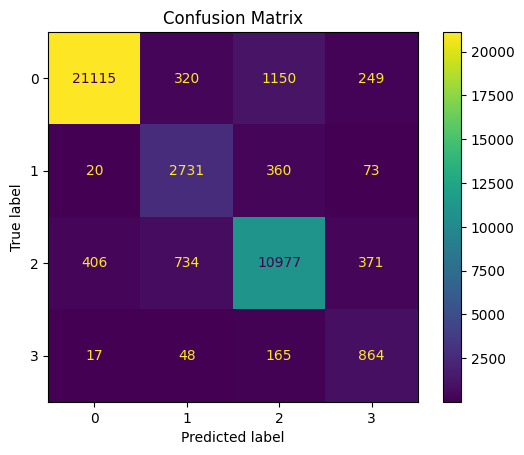

In [53]:
C=confusion_matrix(y_val,y_val_pred)
disp=ConfusionMatrixDisplay(C)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

- Class 0 remained well-classified, with relatively low misclassifications.

- Compared to the raw features baseline, confusion between Class 1 and Class 2 still persisted.

- Class 3 continued to show low false negatives, maintaining strong recall despite being a minority class.

- Misclassification of Class 0 as Class 2 still remained the most common error, suggesting persistent feature similarity between these classes.

### Hyperparameter Tuning

In [ ]:
log_tuned_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LogisticRegression(max_iter=2000,random_state=5))
])

p_grid={
    "model__C":[5,1.00,0.5,0.1], # To control the regularization parameter
    "model__tol":[1e-4,1e-3],    # To control the tolerance of the model
    "model__class_weight":['balanced',{0:1.0,1:2.0,2:1.0,3:3.0},{0:1.0,1:2.0,2:1.0,3:2.5},{0:0.75,1:2.0,2:0.75,3:3.0}]  # To balance the precision and recall scores for minority classes
}

cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=5)

log_search=RandomizedSearchCV(log_tuned_pipeline,p_grid,scoring="f1_macro",cv=cv,verbose=3,n_iter=12,random_state=5)

log_search.fit(X_train,y_train)

index=log_search.best_index_
mean_f1=log_search.best_score_
std_f1=log_search.cv_results_['std_test_score'][index]

print(f"Cross-Validated Macro F1-Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Best Parameters: {log_search.best_params_}")

- ### *Cross-Validated Macro F1-Score:* **0.8165 ± 0.0039**

- ### *Best Parameters:* **{'model__tol': 0.0001, 'model__class_weight': {0: 1.0, 1: 2.0, 2: 1.0, 3: 3.0}, 'model__C': 0.5}**

In [54]:
log_tuned_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LogisticRegression(class_weight={0: 1.0, 1: 2.0, 2: 1.0, 3: 3.0},C=0.5,max_iter=2000,random_state=5))
])

log_tuned_pipeline.fit(X_train,y_train)

y_val_pred=log_tuned_pipeline.predict(X_val)

y_train_pred=log_tuned_pipeline.predict(X_train)
y_val_pred=log_tuned_pipeline.predict(X_val)

macro_f1_train=f1_score(y_train,y_train_pred,average='macro')
macro_f1_val=f1_score(y_val,y_val_pred,average='macro')

print("Training Macro F1-Score:",round(macro_f1_train,4))
print("Validation Macro F1-Score:",round(macro_f1_val,4))

Training Macro F1-Score: 0.8999
Validation Macro F1-Score: 0.8273


- ### *Training Macro F1-Score:* **0.8999**
  
- ### *Validation Macro F1-Score:* **0.8273**

- The tuned model still showed signs of moderate overfitting however, the gap between training and validation scores reduced as compared to the baseline which indicates improved generalization.

In [55]:
print(classification_report(y_val,y_val_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96     22834
           1       0.76      0.83      0.79      3184
           2       0.86      0.90      0.88     12488
           3       0.67      0.69      0.68      1094

    accuracy                           0.91     39600
   macro avg       0.82      0.84      0.83     39600
weighted avg       0.91      0.91      0.91     39600



- Compared to the baseline model with transformed features, the tuned model showed a notable improvement in the precision scores for minority classes. 

- This improvement also indicated a better balance between precision and recall scores.

- Overall, the increase in macro-averaged F1-score suggests improved performance across all classes.

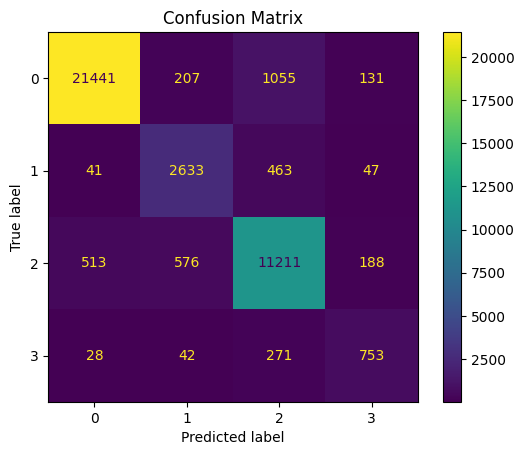

In [56]:
C=confusion_matrix(y_val,y_val_pred)
disp=ConfusionMatrixDisplay(C)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

### The observations were as follows:
- Class 0 remained well-classified, with a slight reduction in misclassifications compared to the baseline model.
   
- Confusion between Class 1 and Class 2 still persisted, indicating continued overlap in their feature patterns.

- Class 3 showed an increase in false negatives compared to the baseline, reflecting a drop in recall scores.

- Misclassification of Class 0 as Class 2 slightly reduced, suggesting marginal improvement in class separation.

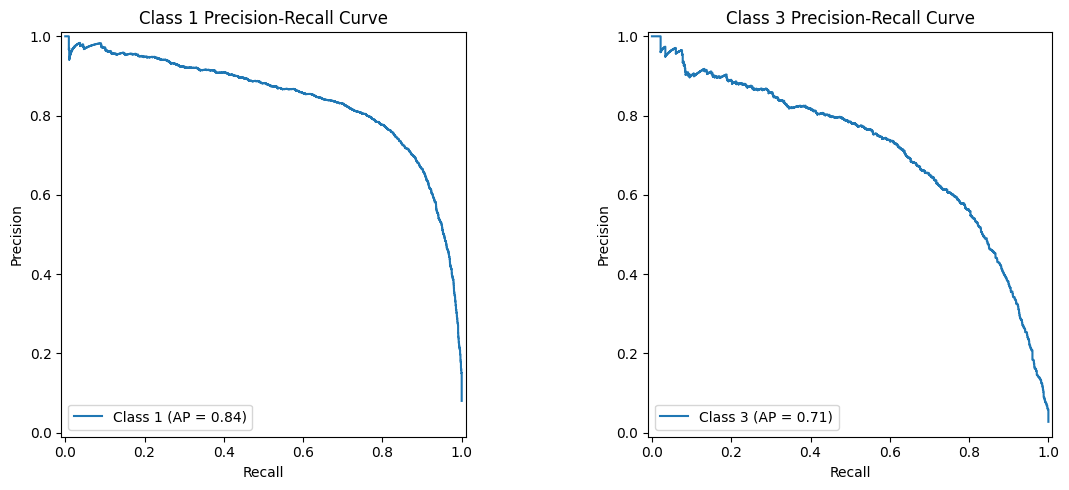

In [57]:
y_val_bin = label_binarize(y_val, classes=[0,1,2,3])

probs = log_tuned_pipeline.predict_proba(X_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
classes=[1,3]

for x in range(len(classes)):
    PrecisionRecallDisplay.from_predictions(y_val_bin[:, classes[x]],probs[:, classes[x]],ax=axes[x],name=f"Class {classes[x]}")
    
    axes[x].set_xlabel("Recall")
    axes[x].set_ylabel("Precision")
    
    axes[x].set_title(f"Class {classes[x]} Precision-Recall Curve")

plt.tight_layout()
plt.show()

### The observations were as follows:
- Class 1 showed relatively stable precision across a wide range of recall values, with an Average Precision (AP) score of 0.84, indicating strong performance.

- In contrast, Class 3 showed a steeper decline in precision as recall increased, resulting in a lower AP score of 0.71, suggesting weaker performance and greater difficulty in correctly identifying this class at higher recall levels.

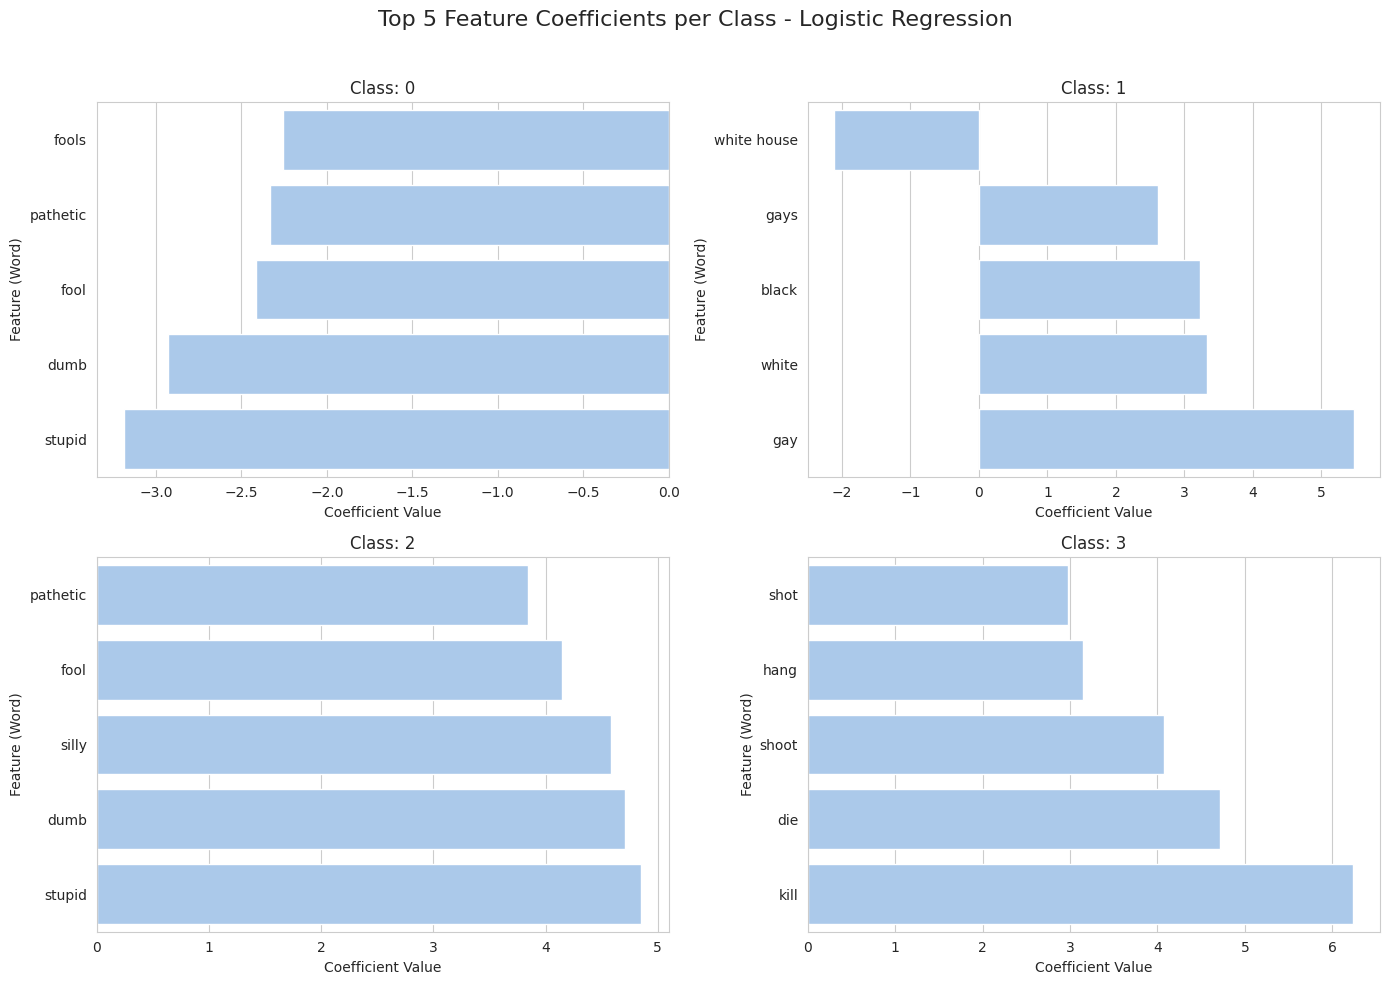

In [71]:
feature_names = (log_tuned_pipeline.named_steps['encode_scale'].named_transformers_['tfidf_word'].get_feature_names_out())
model = log_tuned_pipeline.named_steps['model']

top_n = 5
classes = model.classes_

fig,axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, class_label in enumerate(classes):

    feature_weights = model.coef_[i]

    feature_importance = sorted(zip(feature_names, feature_weights[:len(feature_names)]),key=lambda x: abs(x[1]),reverse=True)

    top_feature_names = [f[0] for f in feature_importance[:top_n]]
    top_coefficients = [f[1] for f in feature_importance[:top_n]]

    sns.barplot(x=top_coefficients[::-1],y=top_feature_names[::-1],ax=axes[i])

    axes[i].set_title(f'Class: {class_label}')
    axes[i].set_xlabel('Coefficient Value')
    axes[i].set_ylabel('Feature (Word)')

fig.suptitle('Top 5 Feature Coefficients per Class - Logistic Regression',fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## The observations were as follows:
* For Class 0, neutral language patterns observed during text analysis were also confirmed through feature importance.

* For Class 2, overlapping vocabulary patterns identified during text analysis were similarly reflected in the important features.

* For Class 1, hateful and discriminatory language observed during EDA was confirmed through highly weighted features.

* For Class 3, violent and offensive expressions identified during exploratory analysis were also reflected in the feature importance results.

* Overall, the feature importance analysis confirmed the language patterns identified during EDA.


## LinearSVC

### About the model:
- Support Vector Machine is a supervised machine learning algorithm used primarily for classification tasks.

- It finds an optimal hyperplane that best seperates different classes by maximizing the margin between them.

- LinearSVC is a fast and scalable implementation of a linear Support Vector Classifier in sklearn.

- For multiclass classification, it uses a One-vs-Rest (OvR) strategy, where separate binary classifiers are trained for each class. 

### Baseline Model

In [66]:
SVC_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LinearSVC(max_iter=5000,random_state=5))
])

SVC_pipeline.fit(X_train,y_train)

y_val_pred=SVC_pipeline.predict(X_val)
y_train_pred=SVC_pipeline.predict(X_train)

macro_f1_val=f1_score(y_val,y_val_pred,average='macro')
macro_f1_train=f1_score(y_train,y_train_pred,average='macro')

print("Training Macro F1-Score:",round(macro_f1_train,4))
print("Validation Macro F1-Score:",round(macro_f1_val,4))

Training Macro F1-Score: 0.9847
Validation Macro F1-Score: 0.8014


- ### *Training Macro F1-Score:* **0.9847**

- ### *Validation Macro F1-Score:* **0.8014**
  
- The model showed significant overfitting, as indicated by the large gap between training and validation scores.

In [67]:
print(classification_report(y_val,y_val_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94     22834
           1       0.78      0.75      0.76      3184
           2       0.85      0.89      0.87     12488
           3       0.73      0.55      0.63      1094

    accuracy                           0.90     39600
   macro avg       0.83      0.78      0.80     39600
weighted avg       0.90      0.90      0.90     39600



- The model showed relatively balanced precision and recall scores for most classes except, class 3 which had notably lower recall score, indicating that many samples of this class were missed.

- Majority classes (class 0 and class 2) were well-classified, with balanced precision and recall scores.  

- Overall, the model achieved a decent baseline performance.

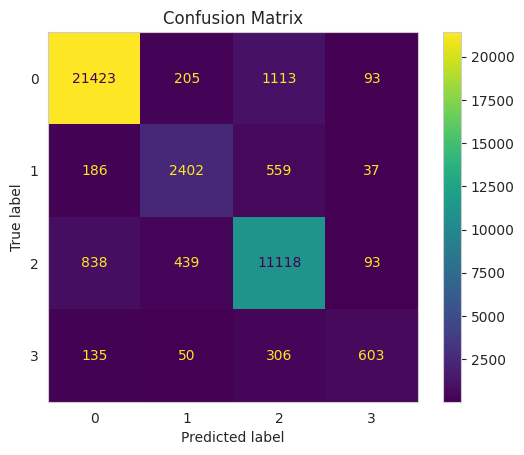

In [75]:
C=confusion_matrix(y_val,y_val_pred)
disp=ConfusionMatrixDisplay(C)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

- The model performed well on the majority class (Class 0).  

- There was a notable confusion between Class 0 and Class 2, indicating similarity in their feature space. 

- Minority classes, especially Class 3, showed lower recall, with many samples misclassified as Class 2.

### Hyperparameter Tuning


In [ ]:
SVC_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LinearSVC(max_iter=10000,random_state=5,loss="hinge"))
])

p_grid={
    "model__C": [0.25,0.5,1], # To control the regularization paramater
    "model__class_weight":['balanced',{0: 1.0, 1: 2.0, 2: 1.0, 3: 3.0},{0: 1.0, 1: 2.0, 2: 1.0, 3: 2.5},{0: 0.75, 1: 2.0, 2: 0.75, 3: 3.0}] # To balance the precision and recall scores
}


cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=5)

SVC_search=RandomizedSearchCV(SVC_pipeline,p_grid,scoring="f1_macro",cv=cv,verbose=3)

SVC_search.fit(X_train,y_train)

index=SVC_search.best_index_
mean_f1=SVC_search.best_score_
std_f1=SVC_search.cv_results_['std_test_score'][index]

print(f"Cross-Validated Macro F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Best Parameters: {SVC_search.best_params_}")

- ### *Cross-Validated Macro F1 Score:* **0.8180 ± 0.0039**
- ### *Best Parameters:* **{'model__class_weight': {0: 0.75, 1: 2.0, 2: 0.75, 3: 3.0}, 'model__C': 0.5}**

In [76]:
SVC_tuned_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LinearSVC(class_weight={0:0.75,1:2,2:0.75,3:3},C=0.5,max_iter=5000,random_state=5))
])

SVC_tuned_pipeline.fit(X_train,y_train)

y_val_pred=SVC_tuned_pipeline.predict(X_val)
y_train_pred=SVC_tuned_pipeline.predict(X_train)

macro_f1_val=f1_score(y_val,y_val_pred,average='macro')
macro_f1_train=f1_score(y_train,y_train_pred,average='macro')

print("Training Macro F1-Score:",round(macro_f1_train,4))
print("Validation Macro F1-Score:",round(macro_f1_val,4))

Training Macro F1-Score: 0.9662
Validation Macro F1-Score: 0.8151


- ### *Training Macro F1-Score:* **0.9662**

- ### *Validation Macro F1-Score:* **0.8151**
  
- The model still showed overfitting however, compared to the baseline model, the gap between training and validation scores reduced, indicating improved generalization.

In [77]:
print(classification_report(y_val,y_val_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22834
           1       0.75      0.80      0.78      3184
           2       0.86      0.89      0.88     12488
           3       0.69      0.63      0.66      1094

    accuracy                           0.90     39600
   macro avg       0.82      0.82      0.82     39600
weighted avg       0.91      0.90      0.90     39600



- Precision and recall scores for minority classes became more balanced, leading to improved f1-scores.

- Class 3 also showed improvement in recall as compared to the baseline, although it was still relatively lower than other classes.

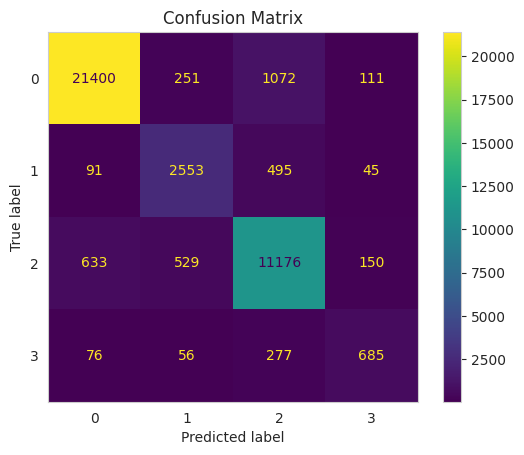

In [79]:
C=confusion_matrix(y_val,y_val_pred)
disp=ConfusionMatrixDisplay(C)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

- The model continued to perform well on the majority class (Class 0).

- Confusion between Class 0 and Class 2 still persisted, although it was slightly reduced compared to the baseline.

- Minority classes showed improved performance, with better classification of Class 1 and Class 3 samples.

- Class 3 recall showed improvement compared to the baseline, although some misclassification with Class 2 still remained.

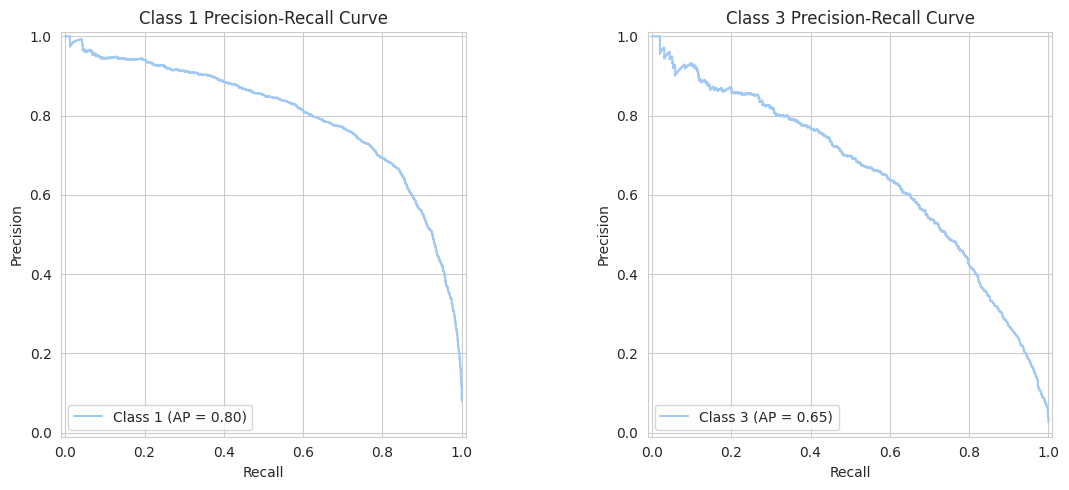

In [80]:
y_val_bin = label_binarize(y_val, classes=[0,1,2,3])

scores = SVC_tuned_pipeline.decision_function(X_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
classes=[1,3]

for x in range(len(classes)):
    PrecisionRecallDisplay.from_predictions(y_val_bin[:, classes[x]],scores[:, classes[x]],ax=axes[x],name=f"Class {classes[x]}")

    axes[x].set_xlabel("Recall")
    axes[x].set_ylabel("Precision")
    
    axes[x].set_title(f"Class {classes[x]} Precision-Recall Curve")

plt.tight_layout()
plt.show()

### The observations were as follows:
- Class 1 showed relatively stable precision across a wide range of recall values, with an Average Precision (AP) score of 0.80, indicating strong performance.

- In contrast, Class 3 showed very steep decline in precision as recall increased, resulting in a low AP score of 0.65, suggesting weak performance.

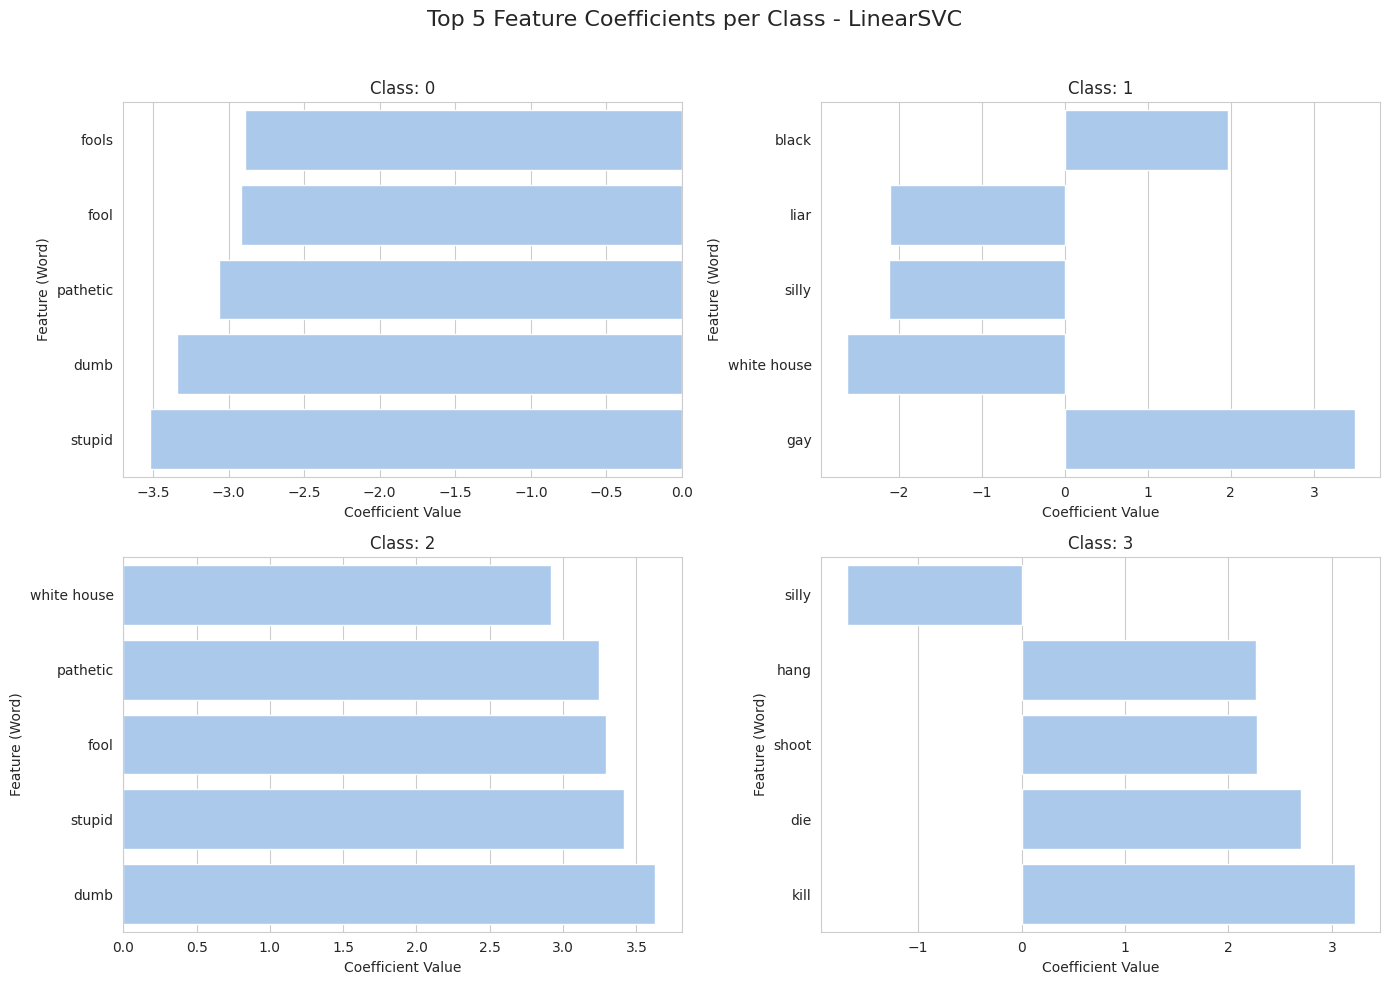

In [81]:
feature_names = (SVC_tuned_pipeline.named_steps['encode_scale'].named_transformers_['tfidf_word'].get_feature_names_out())
model = SVC_tuned_pipeline.named_steps['model']

top_n = 5
classes = model.classes_

fig,axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()
for i, class_label in enumerate(classes):

    feature_weights = model.coef_[i]

    feature_importance = sorted(zip(feature_names, feature_weights[:len(feature_names)]),key=lambda x: abs(x[1]),reverse=True)

    top_feature_names = [f[0] for f in feature_importance[:top_n]]
    top_coefficients = [f[1] for f in feature_importance[:top_n]]

    sns.barplot(x=top_coefficients[::-1],y=top_feature_names[::-1],ax=axes[i])

    axes[i].set_title(f'Class: {class_label}')
    axes[i].set_xlabel('Coefficient Value')
    axes[i].set_ylabel('Feature (Word)')


fig.suptitle('Top 5 Feature Coefficients per Class - LinearSVC',fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## The observations were as follows:

* For Class 0, neutral language patterns observed during text analysis were also confirmed through feature importance.

* For Class 2, overlapping vocabulary patterns identified during text analysis were similarly reflected in the important features.

* For Class 1, hateful and discriminatory language observed during EDA was confirmed through highly weighted features.

* For Class 3, violent and offensive expressions identified during exploratory analysis were also reflected in the feature importance results.

* Overall, the feature importance analysis confirmed the linguistic patterns identified during EDA.


## LightGBM Classifier

### About the model:
- LightGBMClassifier is a gradient boosting framework that uses tree-based algorithms for classification tasks.
  
- It grows trees leaf-wise instead of level-wise where it chooses that leaf with the maximum reduction in loss (delta loss) at each step.

- Being a tree-based model, it captures non-linear relationships between features and the target variable.

### LightGBM Model Pipeline

In [5]:
def clean_preprocess_lightgbm(df):
    df = df.copy()
    
    df['created_date'] = pd.to_datetime(df['created_date'])
    df['hour'] = df['created_date'].dt.hour
    df['month'] = df['created_date'].dt.month
    df['year'] = df['created_date'].dt.year
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    
    df['comment'] = (df['comment'].fillna("").str.replace(r'\s+', ' ', regex=True).str.strip())
    df['comment_length'] = df['comment'].str.len()
    df['comment_word_count'] = df['comment'].str.split().str.len()
    df['avg_word_length'] = np.where(df['comment_word_count'] > 0,df['comment_length'] / df['comment_word_count'],0)
    
    df['disability'] = df['disability'].fillna(0).astype(int)
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    df['emoticon_1_binary'] = (df['emoticon_1'] > 0).astype(int)
    df['emoticon_2_binary'] = (df['emoticon_2'] > 0).astype(int)
    df['emoticon_3_binary'] = (df['emoticon_3'] > 0).astype(int)
    df['if_1_binary'] = (df['if_1'] > 0).astype(int)
    df['downvote_binary'] = (df['downvote'] > 0).astype(int)
   
    
    df.drop(['created_date', 'post_id', 'hour', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'downvote', 'comment_length', 'month'], axis=1, inplace=True, errors='ignore')
    return df

clean_preprocess_transformer = FunctionTransformer(clean_preprocess_lightgbm)

binary_features=['emoticon_1_binary', 'emoticon_2_binary', 'emoticon_3_binary','if_1_binary', 'downvote_binary', 'disability']
yeo_features=['upvote','if_2', 'comment_word_count','avg_word_length']
temporal_features=['month_sin','month_cos', 'year','hour_sin', 'hour_cos']
categorical_features=['race', 'religion', 'gender']


col_trans=ColumnTransformer([("tfidf_word", TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2), min_df=2, max_features=50000, max_df=0.8, analyzer="word"), "comment"),
                               ("tfidf_char", TfidfVectorizer(sublinear_tf=True, ngram_range=(3,6), min_df=2, max_features=75000, max_df=0.8, analyzer="char_wb"), "comment"),
                               ("yeo_transform", PowerTransformer(method="yeo-johnson",standardize=False), yeo_features),
                               ("impute_encode",Pipeline([
                                   ("si",SimpleImputer(strategy="constant",fill_value="Missing"))
                                   ,("ohe",OneHotEncoder(drop='first', handle_unknown='ignore'))])
                                ,categorical_features)
                            ], remainder='passthrough')


lightGBM_pipeline=Pipeline([('clean_preprocess', clean_preprocess_transformer),
                              ('encode_transform', col_trans)])


set_config(display='diagram')
lightGBM_pipeline

Pipeline(steps=[('clean_preprocess',
                 FunctionTransformer(func=<function clean_preprocess_lightgbm at 0x7ea07d2bb740>)),
                ('encode_transform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tfidf_word',
                                                  TfidfVectorizer(max_df=0.8,
                                                                  max_features=50000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True),
                                                  'comment'),
                                                 ('tfidf_char',
                                                  TfidfVectorizer(analyzer='ch...
                                                                  ngram_range=(3,
                                                                               6),
                                                                  sublinear_tf=True),
                                                  'comment'),
                                                 ('yeo_transform',
                                                  PowerTransformer(standardize=False),
                                                  ['upvote', 'if_2',
                                                   'comment_word_count',
                                                   'avg_word_length']),
                                                 ('impute_encode',
                                                  Pipeline(steps=[('si',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['race', 'religion',
                                                   'gender'])]))])

### Baseline Model

In [7]:
LGBM_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LGBMClassifier(objective='multiclass',class_weight='balanced',n_jobs=-1,random_state=5,device="gpu",verbose=None))
])

LGBM_pipeline.fit(X_train,y_train)

y_val_pred=LGBM_pipeline.predict(X_val)
y_train_pred=LGBM_pipeline.predict(X_train)

macro_f1_val=f1_score(y_val,y_val_pred,average='macro')
macro_f1_train=f1_score(y_train,y_train_pred,average='macro')

print("Training Macro F1-Score:",round(macro_f1_train,4))
print("Validation Macro F1-Score:",round(macro_f1_val,4))

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 10812540
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 124887
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 69 dense feature groups (10.88 MB) transferred to GPU in 0.016475 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training Macro F1-Score: 0.8441
Validation Macro F1-Score: 0.8003


- ### *Training Macro F1-Score:* **0.8441**

- ### *Validation Macro F1-Score:* **0.8003**
  
- The model showed relatively balanced performance, as the gap between training and validation scores was small, indicating good generalization.

In [8]:
print(classification_report(y_val,y_val_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22834
           1       0.69      0.89      0.78      3184
           2       0.89      0.84      0.87     12488
           3       0.47      0.81      0.60      1094

    accuracy                           0.90     39600
   macro avg       0.76      0.87      0.80     39600
weighted avg       0.92      0.90      0.91     39600



- The precision score for minority classes was relatively lower, especially for Class 3.

- However, recall scores for minority classes was high, suggesting that the model overpredicted these classes.

- Majority classes (Class 0 and Class 2) showed more balanced precision and recall scores.

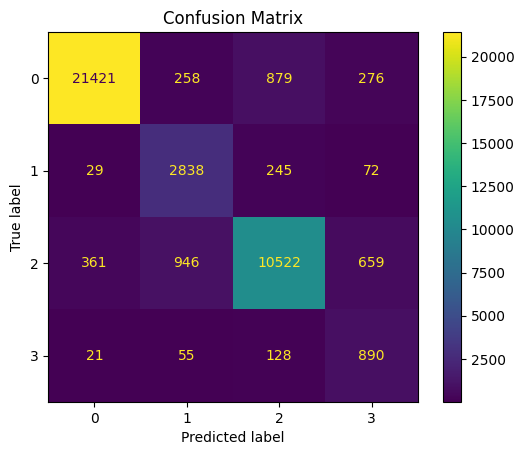

In [9]:
C=confusion_matrix(y_val,y_val_pred)
disp=ConfusionMatrixDisplay(C)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

- Class 0 remained well-classified overall.  

- There was notable confusion between Class 1 and Class 2, indicating overlap in their feature space.

- Class 2 was the hardest to classify, with misclassifications across multiple classes  

- Class 3 was relatively well-classified, showing strong recall despite being a minority class.

### Hyperparameter Tuning (Manual)

### Manual Hyperparameter Tuning Runs

| Run | Class Weight (Class 3) | num_leaves | max_depth | subsample | Validation Macro F1 |
| --- | ---------------------- | ---------- | --------- | --------- | ------------------- |
| 1   | 4                      | –          | –         | –         | 0.8334              |
| 2   | 6                      | 62         | –         | –         | **0.8353 (Best)**   |
| 3   | 6                      | 31         | 6         | 0.7       | 0.8222              |
| 4   | 6                      | 63         | –         | 0.8       | 0.8326              |
| 5   | 5                      | 63         | –         | 0.8       | 0.8315              |


In [6]:
LGBM_tuned_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LGBMClassifier(objective='multiclass',class_weight ={0:1,1:3,2:1,3:6}, num_leaves=62, n_estimators=600, learning_rate=0.05, min_child_samples=100, colsample_bytree=0.7, reg_lambda=2, n_jobs=-1,random_state=5, verbose=None,device="gpu"))
])

LGBM_tuned_pipeline.fit(X_train,y_train)

y_val_pred=LGBM_tuned_pipeline.predict(X_val)
y_train_pred=LGBM_tuned_pipeline.predict(X_train)

macro_f1_val=f1_score(y_val,y_val_pred,average='macro')
macro_f1_train=f1_score(y_train,y_train_pred,average='macro')

print("Training Macro F1-Score:",round(macro_f1_train,4))
print("Validation Macro F1-Score:",round(macro_f1_val,4))

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9839327
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 75366
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 69 dense feature groups (10.88 MB) transferred to GPU in 0.014451 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -0.812056
[LightGBM] [Info] Start training from score -1.683735
[LightGBM] [Info] Start training from score -1.415560
[LightGBM] [Info] Start training from score -2.058957
Training Macro F1-Score: 0.9777
Validation Macro F1-Score: 0.8353


- ### *Training Macro F1-Score:* **0.9777**

- ### *Validation Macro F1-Score:* **0.8353**
  
- The model showed significant overfitting, as indicated by the gap between training and validation scores.

In [7]:
print(classification_report(y_val,y_val_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22834
           1       0.76      0.85      0.80      3184
           2       0.88      0.90      0.89     12488
           3       0.69      0.69      0.69      1094

    accuracy                           0.92     39600
   macro avg       0.82      0.85      0.84     39600
weighted avg       0.92      0.92      0.92     39600



- The model showed strong performance across most classes, with high precision and recall scores. 

- Class 1, showed well-balanced precision and recall scores. 

- Class 3 showed improved and balanced precision and recall compared to the baseline model, but still remained the lowest performing class.

- Overall, the model achieved strong performance with a high macro F1-score.  

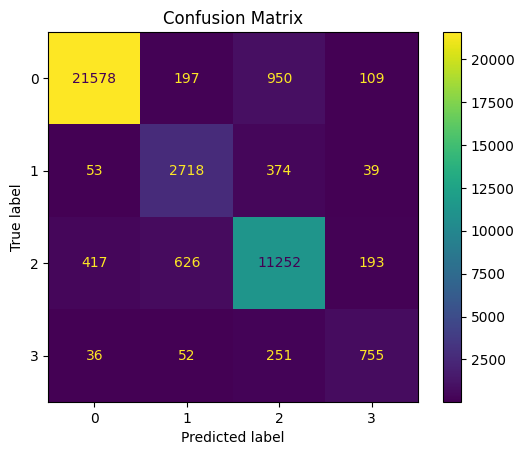

In [8]:
C=confusion_matrix(y_val,y_val_pred)
disp=ConfusionMatrixDisplay(C)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

- Class 0 remained well-classified overall. 

- There was noticeable confusion between Class 0 and Class 2, indicating overlap in their feature space.

- Class 2 showed misclassification across multiple classes, suggesting it was harder to classify. 

- Class 3 had the lowest false positives, indicating more precise predictions despite being a minority class.

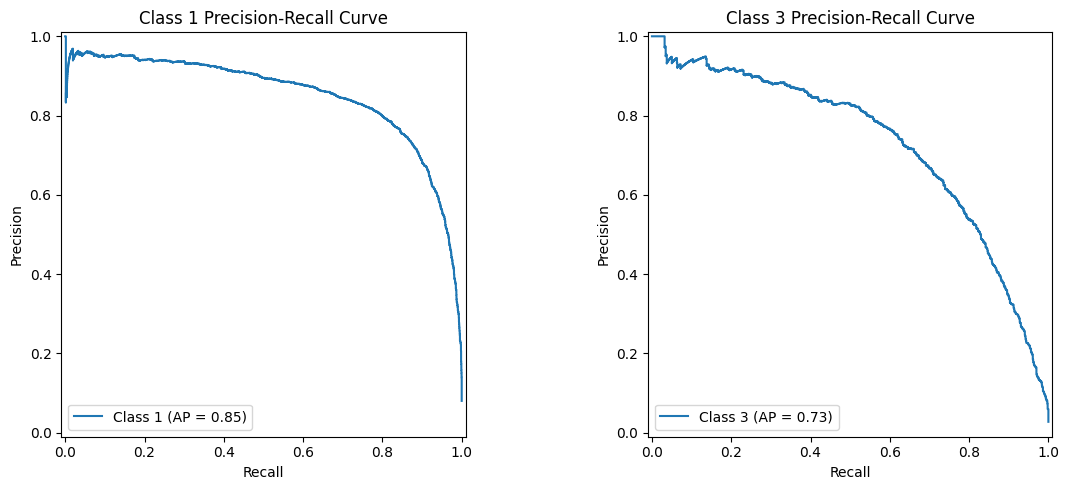

In [9]:
y_val_bin = label_binarize(y_val, classes=[0,1,2,3])

prob = LGBM_tuned_pipeline.predict_proba(X_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
classes=[1,3]

for x in range(len(classes)):
    PrecisionRecallDisplay.from_predictions(y_val_bin[:, classes[x]],prob[:, classes[x]],ax=axes[x],name=f"Class {classes[x]}")

    axes[x].set_xlabel("Recall")
    axes[x].set_ylabel("Precision")
    
    axes[x].set_title(f"Class {classes[x]} Precision-Recall Curve")

plt.tight_layout()
plt.show()

### The observations were as follows:
- Class 1 showed relatively stable precision across a wide range of recall values, with an Average Precision (AP) score of 0.85, indicating strong performance.

- In contrast, Class 3 showed some decline in precision as recall increased, resulting in a lower AP score of 0.73, indicating comparatively lower performance.

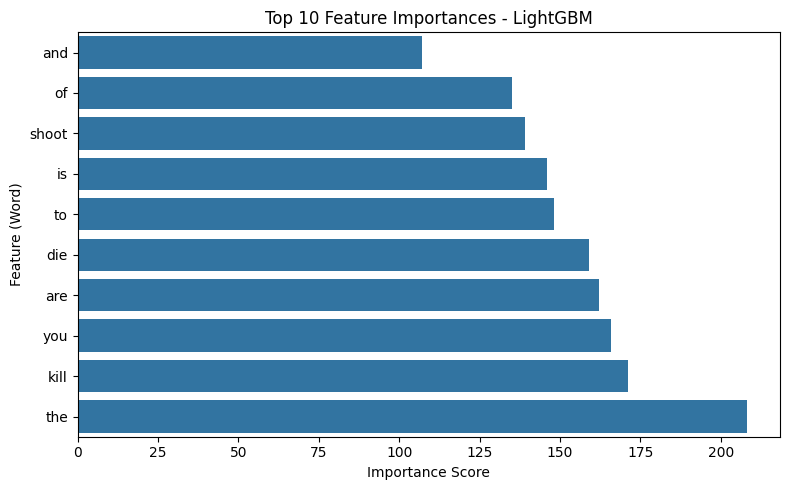

In [10]:
feature_names = (LGBM_tuned_pipeline.named_steps['encode_scale'].named_transformers_['tfidf_word'].get_feature_names_out())
model = LGBM_tuned_pipeline.named_steps['model']

feature_weights = model.feature_importances_

feature_importance = sorted(zip(feature_names, feature_weights[:len(feature_names)]),key=lambda x: abs(x[1]),reverse=True)
top_n = 10

top_feature_names = [f[0] for f in feature_importance[:top_n]]
top_coefficients = [f[1] for f in feature_importance[:top_n]]

fig,ax = plt.subplots(figsize=(8, 5))

sns.barplot(x=top_coefficients[::-1],y=top_feature_names[::-1],ax=ax)

ax.set_title('Top 10 Feature Importances - LightGBM')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature (Word)')

plt.tight_layout()
plt.show()

## The observations were as follows:
* The top important features reflected the most influential textual patterns used by the LightGBM model for classification.

* Several important features aligned with the hateful, offensive, and overlapping vocabulary patterns identified during EDA.

# Model Performance Comparison

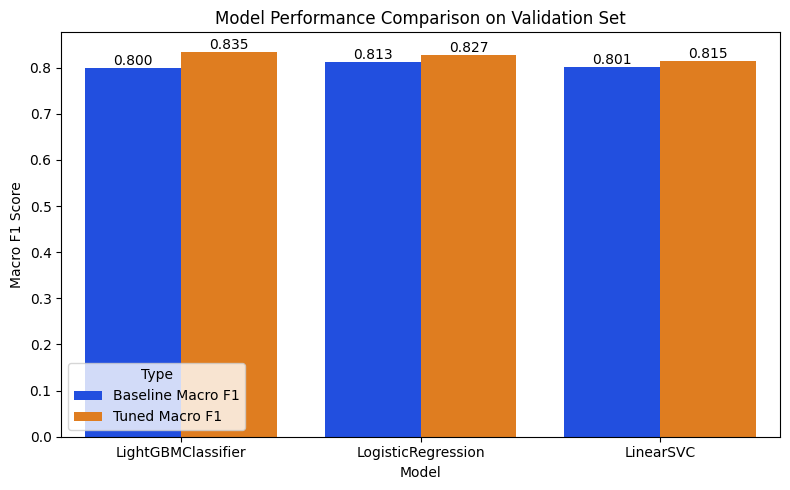

In [11]:
results=pd.DataFrame({'Model': ['LogisticRegression','LinearSVC', 'LightGBMClassifier'],'Baseline Macro F1': [0.813, 0.801, 0.800],'Tuned Macro F1': [0.827, 0.815, 0.835]})

results.sort_values(by='Tuned Macro F1', ascending=False, inplace=True)

df_plot = results.melt(id_vars='Model', var_name='Type', value_name='Score')
plt.figure(figsize=(8,5))

ax = sns.barplot(data=df_plot, x='Model', y='Score', hue='Type',palette="bright")
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title('Model Performance Comparison on Validation Set')
plt.ylabel('Macro F1 Score')
plt.tight_layout()
plt.show()

# Submission

In [ ]:
best_pipeline=Pipeline([
    ('clean_preprocess',clean_preprocess_transformer),
    ('encode_scale',col_trans),
    ('model',LGBMClassifier(objective='multiclass',class_weight ={0:1,1:3,2:1,3:6}, num_leaves=62, n_estimators=600, learning_rate=0.05, min_child_samples=100, colsample_bytree=0.7, reg_lambda=2, n_jobs=-1,random_state=5, device="gpu", verbose=None))
])
best_pipeline.fit(X_train,y_train)

y_val_pred=best_pipeline.predict(X_val)
y_train_pred=best_pipeline.predict(X_train)

macro_f1_val=f1_score(y_val,y_val_pred,average='macro')
macro_f1_train=f1_score(y_train,y_train_pred,average='macro')

print("Training Macro F1-Score:",round(macro_f1_train,4))
print("Validation Macro F1-Score:",round(macro_f1_val,4))

X_full_train=pd.concat([X_train,X_val],axis=0)
y_full_train=pd.concat([y_train,y_val],axis=0)

best_pipeline.fit(X_full_train,y_full_train)

y_pred=best_pipeline.predict(X_test)

submission=pd.DataFrame({'ID':range(1,X_test.shape[0]+1),'label':y_pred})
submission.to_csv('submission.csv',index=False)

#### Submission Macro F1-Scores:
- *Logistic Regression*: **0.8243**
- *Linear SVC*: **0.8181**
- *LightGBM Classifier*: **0.8344**